# Residual Structure and Uncertainty Experiments

In this notebook, the residual diagnostics from final validation are treated as scientific motivation for new experiments, not as a reopening of the confirmatory holdout. The goal is to evaluate, solely on the development set, whether the temporal structure of volatility can be represented by new features, a probabilistic loss function, or a prequential residual-scale layer.

The results should be read as a controlled investigation. If any design performs favorably, it will be described only as an experimental successor candidate, because confirmation will require an independent window.


In [1]:
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = next(
    filter(
        lambda candidate: (
            (candidate / 'src').is_dir()
            and (candidate / 'notebooks').is_dir()
        ),
        (Path.cwd(), *Path.cwd().parents),
    )
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from matplotlib import pyplot as plt

from src import uncertainty_reports as reports
from src.i18n import make_lang
from src.plotting import set_graph_parameters
from src.uncertainty_experiments import (
    UncertaintyExperimentConfig,
    experiment_specs,
    load_uncertainty_experiment_results,
    prepare_uncertainty_development,
)

warnings.filterwarnings('ignore', category=FutureWarning)
set_graph_parameters()
plt.rcParams['axes.grid'] = False
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

lang = make_lang('en')

## 1. Objective and Confirmatory Boundary

The final validation in Notebook 05 confirmed `CatBoostRegressor` as the best point prediction model among the frozen candidates. Nevertheless, relevant temporal dependence was observed in the residuals, with persistence at lags of 1, 24, and 168 hours and evidence of ARCH effects even after standardization by demand level and calendar effects.

In this notebook, this evidence is used to develop new hypotheses. The holdout period from December 2023 through November 2024 is not used, and December 2024 remains outside the process. Therefore, no confirmatory decision is made here.


In [2]:
reports.environment_report(lang=lang)

,Item,Value
0,Conda environment,Bike-Sharing
1,Interpreter (sys.executable),Bike-Sharing/python.exe
2,Python version,3.10.20
3,Environment fingerprint,8f80d9216d47a792
4,Differences from environment.yml,none
5,Dependencies declared with the model,"mlflow==2.10.0, cloudpickle==3.1.2, numpy==1.2..."
6,scikit-learn,1.3.2
7,pandas,2.2.3
8,numpy,1.26.4
9,mlflow,2.10.0


## 2. Environment, Data, and Provenance

The `Bike-Sharing` environment is required before any execution. The same preparation routine used in the temporal selection is reused to return only the development set and metadata of the sealed holdout.

The provenance of the Champion manifest is retained as a methodological reference. The pipeline is rebuilt within each fold from the registered specification rather than loaded as a pretrained artifact.


In [3]:
config = UncertaintyExperimentConfig(
    run_mode='full',
    smoke_fold_limit=2,
    smoke_iterations=25,
)
reports.protocol_report(config, lang=lang)

,Item,Value
0,Execution mode,full
1,Nature of the conclusion,candidato sucessor experimental
2,Use of the final holdout,nao utilizado
3,Use of December 2024,nao utilizado
4,Temporal protocol,ForwardMeteorologicalYearSplit sobre desenvolv...
5,Normal-operation folds in smoke mode,todos
6,CatBoost iterations in smoke mode,manifesto
7,Residual operational contract,rolling_one_step_ahead


In [4]:
reports.artifact_hash_report([config.manifest_path.parent], lang=lang)

,Artifact,SHA256
0,dataset/normal_operations/candidates_v4/candid...,dbf4168383ce7df0ee86eb29134b1739a373cc82be022f...
1,dataset/normal_operations/candidates_v4/challe...,b27ab507627c2d1cb917ccdc2b14a4d503147dc3665f14...
2,dataset/normal_operations/candidates_v4/challe...,3518c691fe7c8db7c8db5eb46b14b8a681aa16775581cc...
3,dataset/normal_operations/candidates_v4/champi...,57195bd3badc8d9826c3383dfc3731665d1325620587db...
4,dataset/normal_operations/candidates_v4/model_...,0dff0d96fa2ab519a009e556e5c41ce62bb3531a556e0f...


## 3. Temporal Protocol and Holdout Blocking

The `ForwardMeteorologicalYearSplit` is preserved so that experiments can be evaluated under the same temporal geometry as the current selection. The structure respects the caution discussed by Bergmeir, Hyndman, and Koo (2018), in which the evaluation of time series should consider serial dependence, non-stationarity, and out-of-sample error. The training windows follow temporal expansion, the gap is maintained, and the `normal_operations` policy continues to separate selection and stress folds. The 2020 hours are kept only in the timeline and stress diagnosis; they are excluded from the adjustment, main scoring, and prequential residual state.

The final holdout is not reopened. The object available for the notebook contains only the development and an auditable summary of the sealed windows.


In [5]:
development = prepare_uncertainty_development(config)
reports.development_report(development, lang=lang)

,Item,Value
0,Development period,19/09/2015 a 30/11/2023
1,Development rows,71490
2,Sealed holdout,"sim, sem retorno de linhas"
3,Excluded post-holdout period,01/12/2024 a 31/12/2024
4,Dataset fingerprint,24f188a95febd94d
5,Regime fingerprint,1043b392ad5e2806
6,Eligible rows,62731
7,Excluded rows,8759


,Fold,Training start,Training end,Test start,Test end,Training rows,Test rows,Actual gap (hours),Seasons in test set,Training contains future years,Meteorological year,Protocol role,Eligible training rows,Excluded training rows,Rows used for selection
0,1,2015-09-19,2018-11-28 23:00:00,2018-12-01,2019-11-30 23:00:00,27689,8715,49.0,"Autumn, Spring, Summer, Winter",False,2019,selection,27689,0,8715
1,2,2015-09-19,2019-11-28 23:00:00,2019-12-01,2020-11-30 23:00:00,36404,8759,49.0,"Autumn, Spring, Summer, Winter",False,2020,stress,36404,0,0
2,3,2015-09-19,2020-11-28 23:00:00,2020-12-01,2021-11-30 23:00:00,45163,8760,49.0,"Autumn, Spring, Summer, Winter",False,2021,selection,37196,7967,8016
3,4,2015-09-19,2021-11-28 23:00:00,2021-12-01,2022-11-30 23:00:00,53923,8759,49.0,"Autumn, Spring, Summer, Winter",False,2022,selection,45164,8759,8759
4,5,2015-09-19,2022-11-28 23:00:00,2022-12-01,2023-11-30 23:00:00,62682,8760,49.0,"Autumn, Spring, Summer, Winter",False,2023,selection,53923,8759,8760


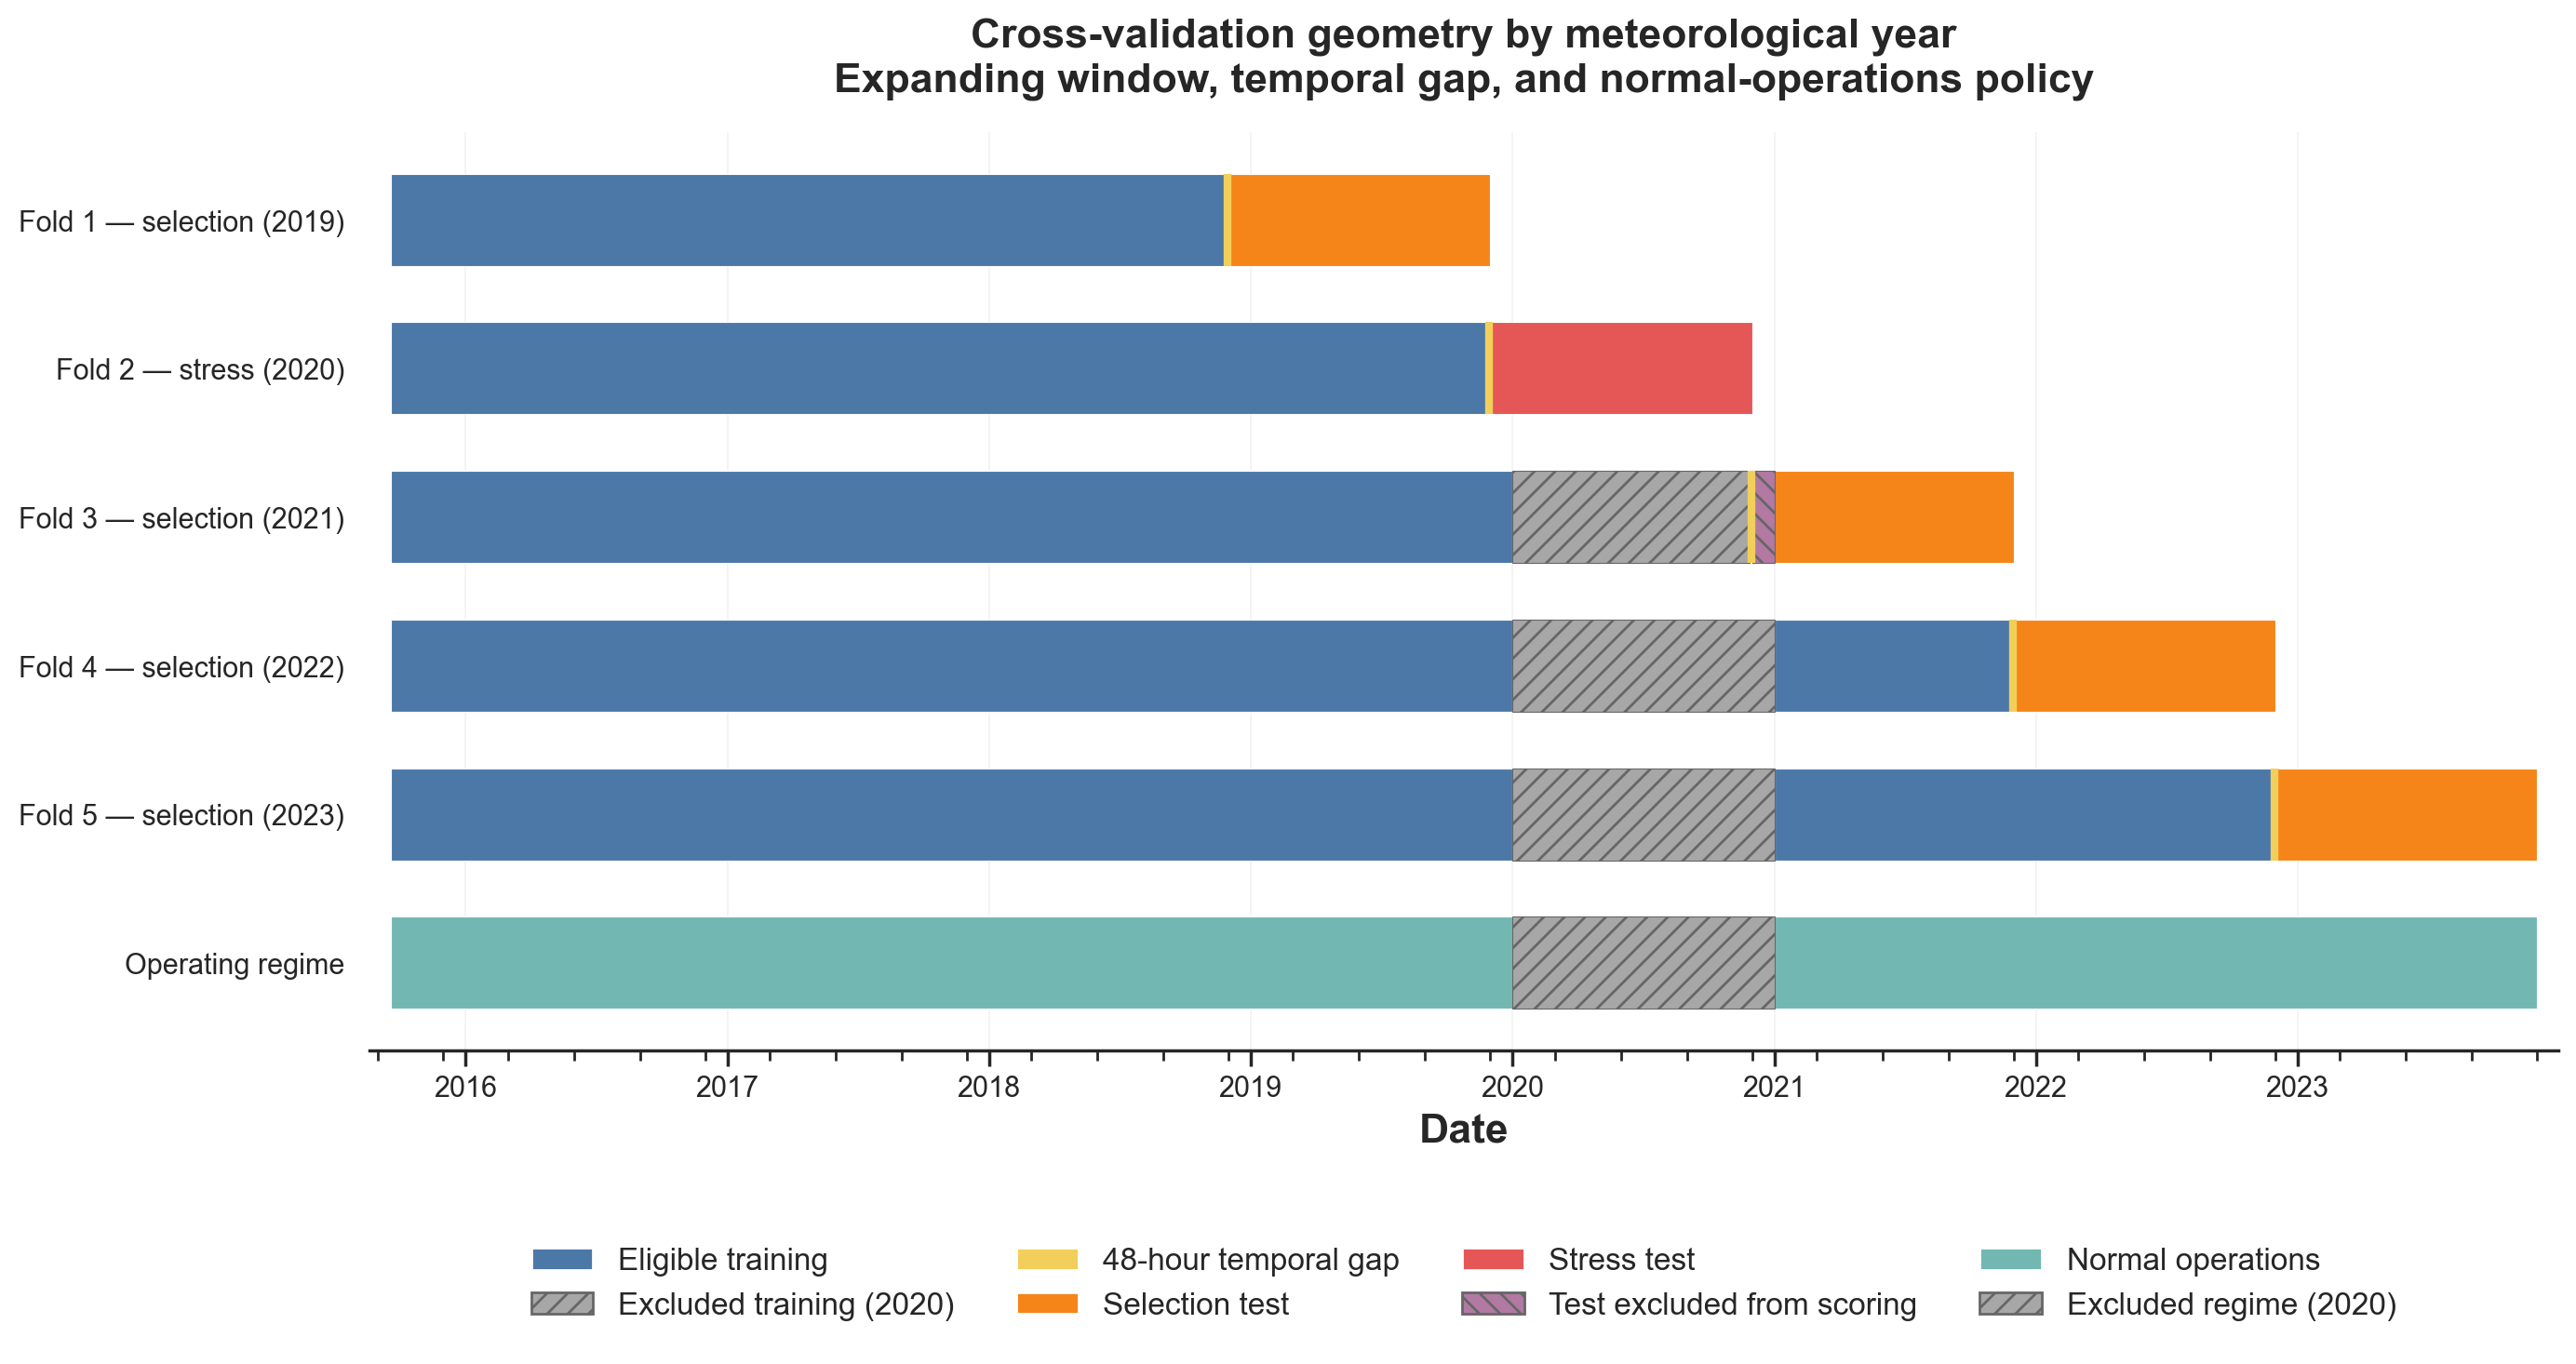

In [6]:
display(reports.fold_audit_report(development, lang=lang))
reports.plot_fold_audit(development, lang=lang)

## 4. Experiment Specification

Five controlled ablations are compared. In E0, the current Champion is reproducibly rebuilt with CatBoost, whose ordered boosting formulation and treatment of categorical features were proposed by Prokhorenkova et al. (2018). In E1, hour-of-week and selected weather interactions are added. In E2, `RMSEWithUncertainty` is evaluated as a probabilistic extension aligned with the gradient-boosting uncertainty literature discussed by Malinin, Prokhorenkova, and Ustimenko (2021). In E3, the probabilistic loss is combined with the new representations. In E4, the residual scale is adjusted using observable absolute-error lags under a rolling one-step-ahead contract.

The new features are treated as exogenous. Because the dataset contains observed weather, the availability of future weather forecasts is assumed as an operational requirement for any eventual production deployment.


In [7]:
reports.experiment_spec_report(experiment_specs(), lang=lang)

,Experiment,Specification,Point model,Uses hour of week,Uses weather interactions,Uses RMSEWithUncertainty,Uses residual scale,Point prediction,Status,Notes
0,E0,Baseline reproduzivel do Champion atual,CatBoostRegressor,No,No,No,No,median,planned,
1,E1,Champion com hora da semana e interacoes meteo...,CatBoostRegressor,Yes,Yes,No,No,median,planned,
2,E2,CatBoost probabilistico sem novas interacoes,CatBoostRegressor,No,No,Yes,No,median,planned,
3,E3,CatBoost probabilistico com interacoes,CatBoostRegressor,Yes,Yes,Yes,No,median,planned,
4,E4,Escala residual prequential com lags observaveis,CatBoostRegressor + scale model,Yes,Yes,Yes,Yes,median,planned,


## 5. Reproducible Baseline E0

E0 serves as a sanity-check control. The same `modeler_name`, encoder, selector, target strategy, and Champion hyperparameters are read from the manifest and refitted within each development fold.

In smoke mode, the iteration count is reduced only to validate the infrastructure. In full mode, the budget registered in the manifest is preserved unless it is explicitly overridden.


## 6. Hour of the Week and Interactions — E1

The `HourOfWeek` column is derived as `dayofweek * 24 + Hour`, with Monday at 00h equal to 0 and Sunday at 23h equal to 167. For tree-based models, this representation is offered as a category, as it allows specific combinations of day and hour to be separated without imposing an artificial linear relationship.

Weather interactions are kept selective. Combinations such as hour of the week with rain, hour of the week with temperature range, and rush period with weather regime are evaluated, preserving interpretability and avoiding combinatorial expansion.


## 7. CatBoost Probabilistic — E2

The `RMSEWithUncertainty` function is evaluated through a dedicated adapter. The `predict` method continues to return a one-dimensional prediction, while `predict_distribution` returns location, variance, standard deviation, and intervals on the original demand scale. This separation between point and distribution follows the motivation for probabilistic prediction in gradient boosting presented by Malinin, Prokhorenkova, and Ustimenko (2021) and is consistent with the general formulation of probabilistic boosting described by Duan et al. (2020).

Because the Champion uses robust trend decomposition, uncertainty is modeled on the logarithmic residual scale. The median of the lognormal distribution is used as the point prediction to preserve compatibility with the primary MAE objective.


## 8. Interactions and Uncertainty — E3

The E3 combines the hypotheses of E1 and E2. Thus, it is evaluated whether the time-of-week structure and meteorology improve not only the central value, but also the predicted scale of the intervals.

This comparison is important because heteroscedasticity can remain even when the mean is well estimated. Therefore, point and probabilistic metrics are reported separately.


## 9. Residual Prequential Volatility — E4

The operational contract adopted is rolling one-step-ahead. At the end of hour `t`, the actual demand is considered consolidated before the forecast for `t+1`, allowing the residual of the previous hour to be used without leakage. The experimental hypothesis is motivated by the ARCH logic of Engle (1982), in which the conditional variance can depend on past shocks.

The 1-, 24-, and 168-hour lags are matched by exact timestamp. During cold start, forecasting is not suspended: the probabilistic scale from E3 is used as a fallback, and the residual correction is activated only after the complete observable memory has matured. After the excluded operational interval, the state is restarted so that no 2020 residual can feed the forecast scale in 2021.


In [8]:
results = load_uncertainty_experiment_results(config, development)

## 10. Point Prediction Comparison

Point metrics are calculated by fold and aggregated across the selection folds using the recency weights already adopted in the project. Weighted MAE remains the primary measure of absolute error, while mean, median, and weighted R² are retained to audit stability.

In `full` mode, the four normal-operation folds are used in the main comparison with the declared recency weights. The 2020 fold is retained in a separate stress table and does not participate in the ranking, probabilistic metrics, or residual diagnostics.


,Experiment,Specification,Point model,Uses hour of week,Uses weather interactions,Uses RMSEWithUncertainty,Uses residual scale,Point prediction,Status,Notes
0,E0,Baseline reproduzivel do Champion atual,CatBoostRegressor,No,No,No,No,median,executed,"{""experiment_id"": ""E0"", ""iterations_override"":..."
1,E1,Champion com hora da semana e interacoes meteo...,CatBoostRegressor,Yes,Yes,No,No,median,executed,"{""experiment_id"": ""E1"", ""iterations_override"":..."
2,E2,CatBoost probabilistico sem novas interacoes,CatBoostRegressor,No,No,Yes,No,median,executed,"{""experiment_id"": ""E2"", ""iterations_override"":..."
3,E3,CatBoost probabilistico com interacoes,CatBoostRegressor,Yes,Yes,Yes,No,median,executed,"{""experiment_id"": ""E3"", ""iterations_override"":..."
4,E4,Escala residual prequential com lags observaveis,CatBoostRegressor + scale model,Yes,Yes,Yes,Yes,median,executed,"{""cold_start_policy"": ""base_or_probabilistic_f..."


,Experiment,Mean MAE,Weighted MAE,Mean RMSE,Mean R2,Median R2,Weighted R2,Mean WAPE,Mean bias,Mean absolute fold bias,MAE standard deviation
0,E0,820.401191,840.165428,1242.845648,0.838691,0.813519,0.857153,0.235199,-400.501401,518.126115,235.514930
1,E3,888.987009,929.471660,1350.334268,0.813802,0.800906,0.829902,0.250732,-455.788471,634.658750,298.552619
2,E4,888.987009,929.471660,1350.334268,0.813802,0.800906,0.829902,0.250732,-455.788471,634.658750,298.552619
3,E1,903.127970,940.308315,1340.587752,0.813502,0.804571,0.829168,0.255896,-485.245045,656.096695,338.259440
4,E2,922.949878,981.579447,1396.453634,0.805831,0.800523,0.817334,0.257975,-408.556510,655.192112,307.768544


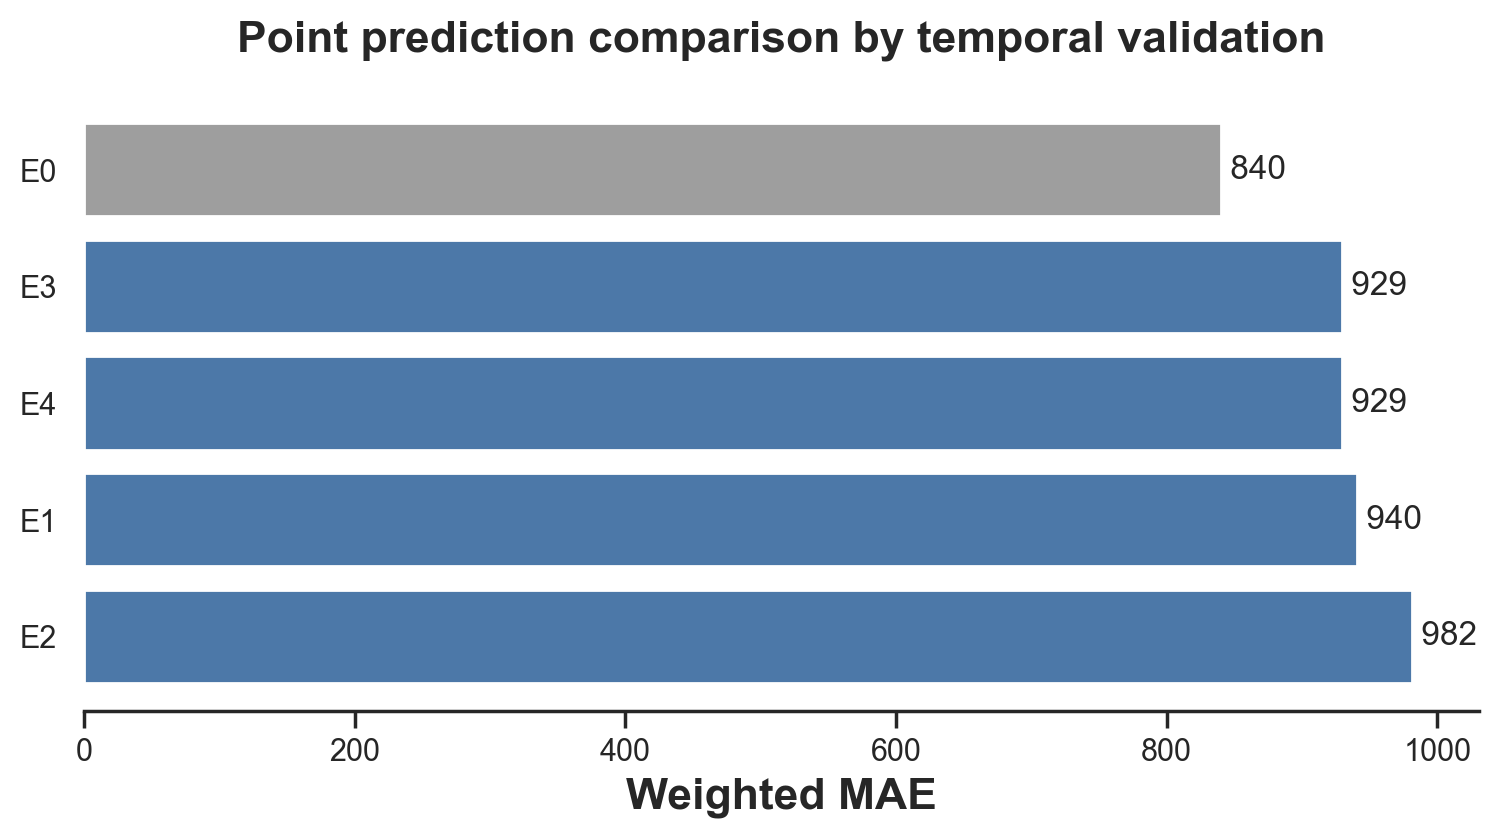

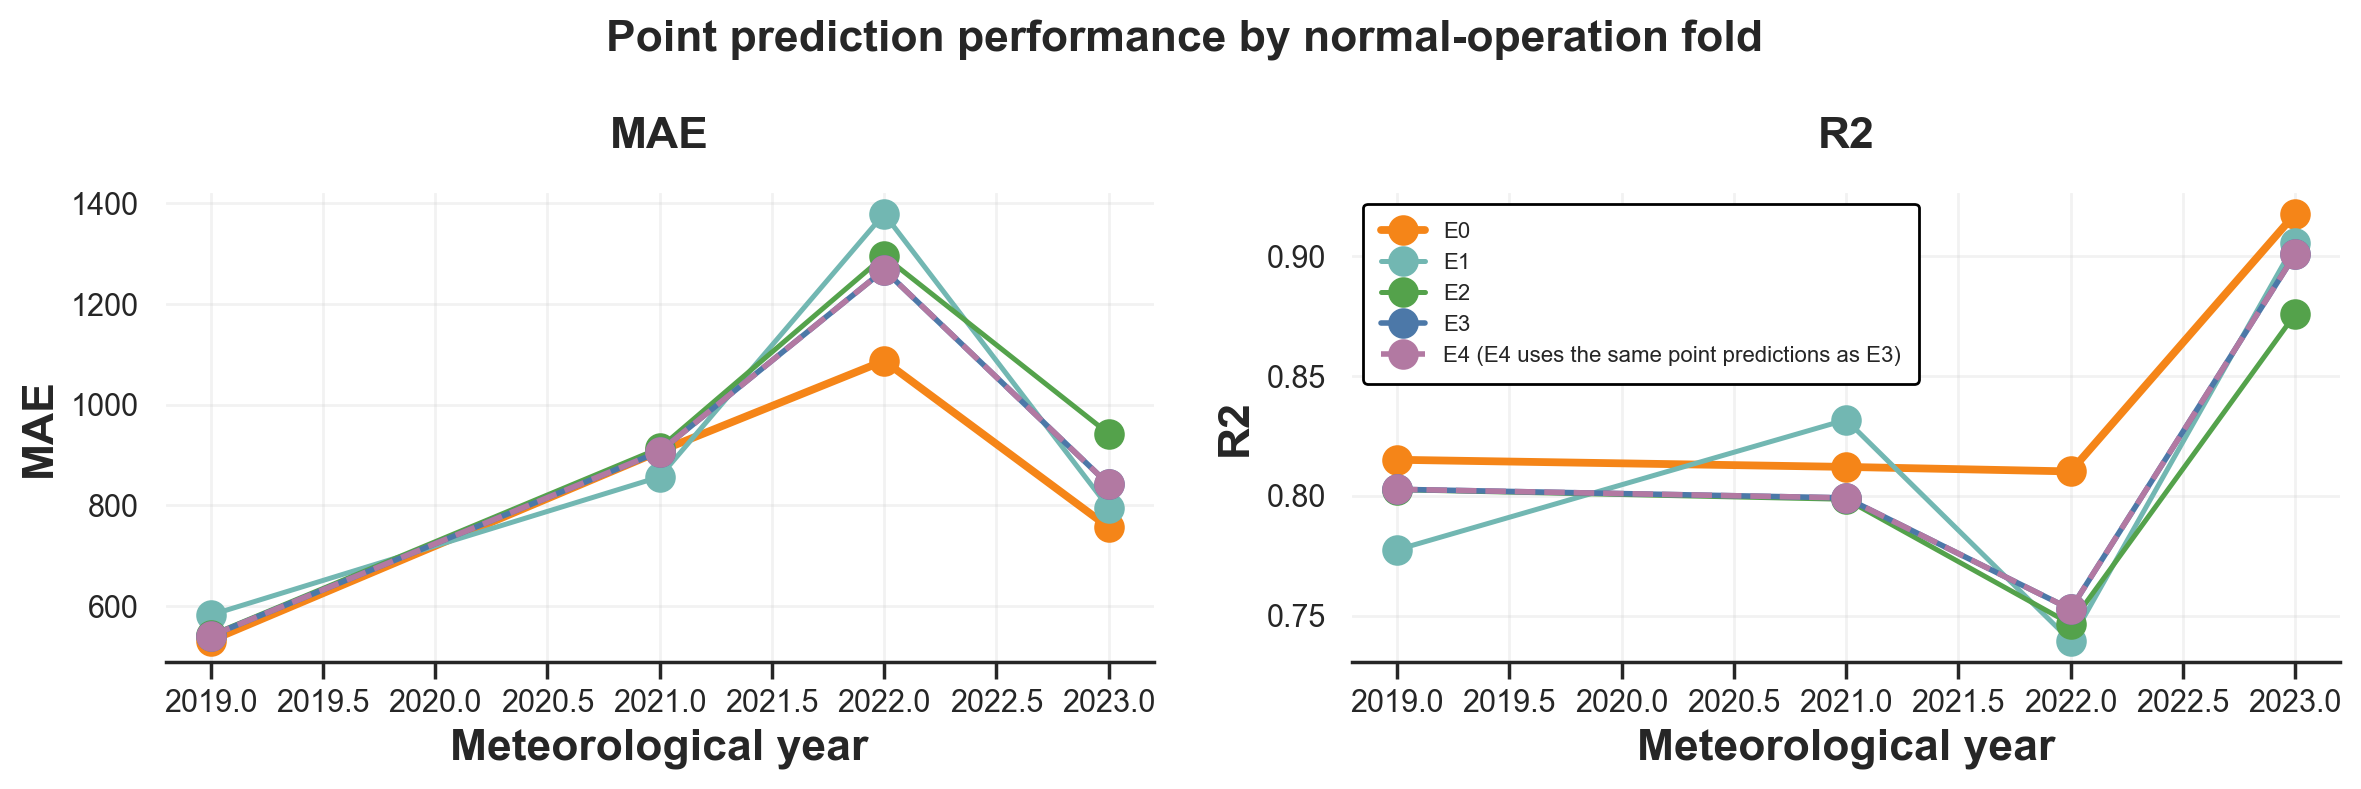

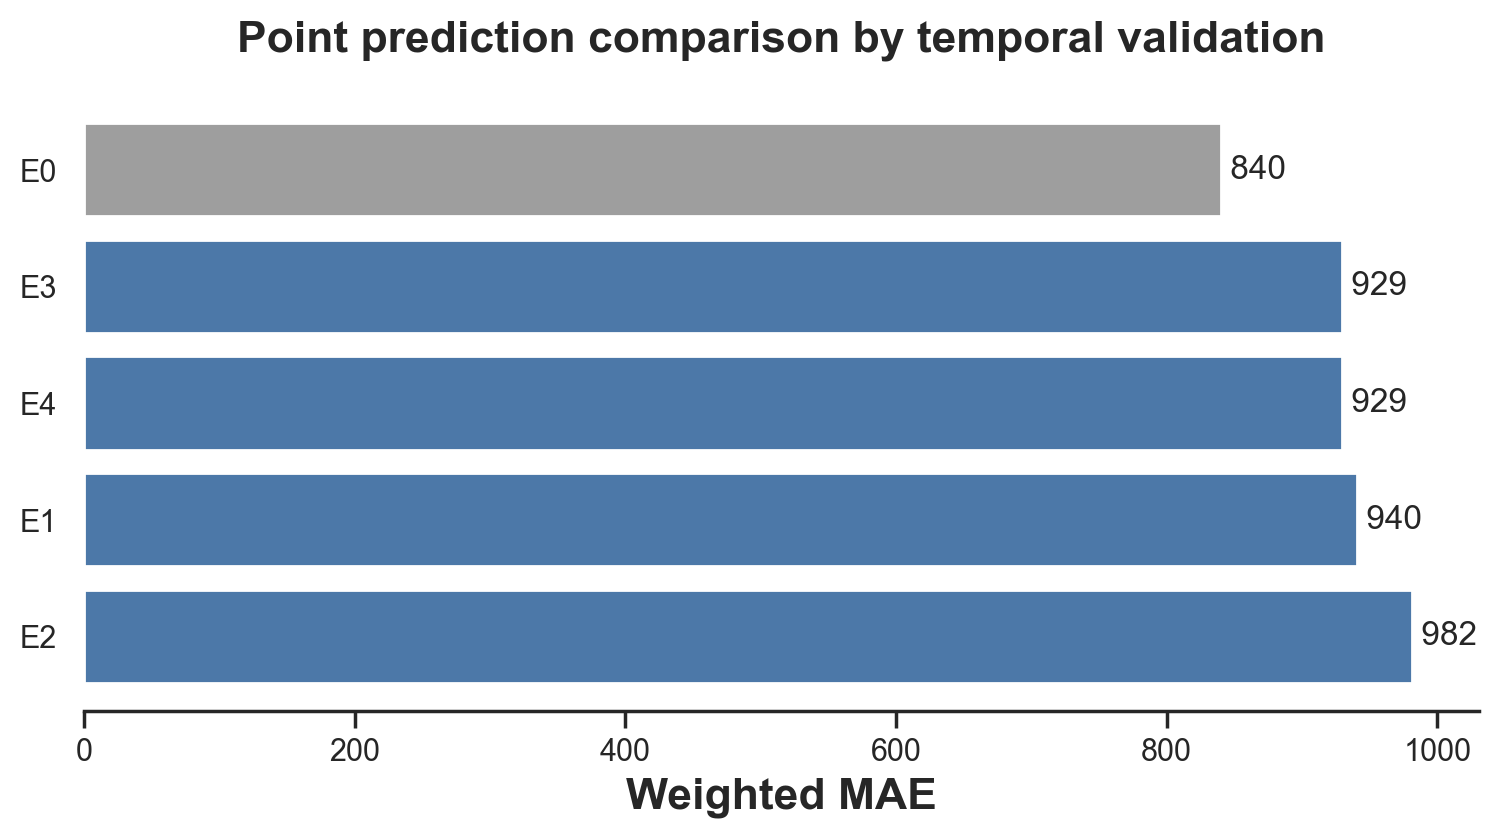

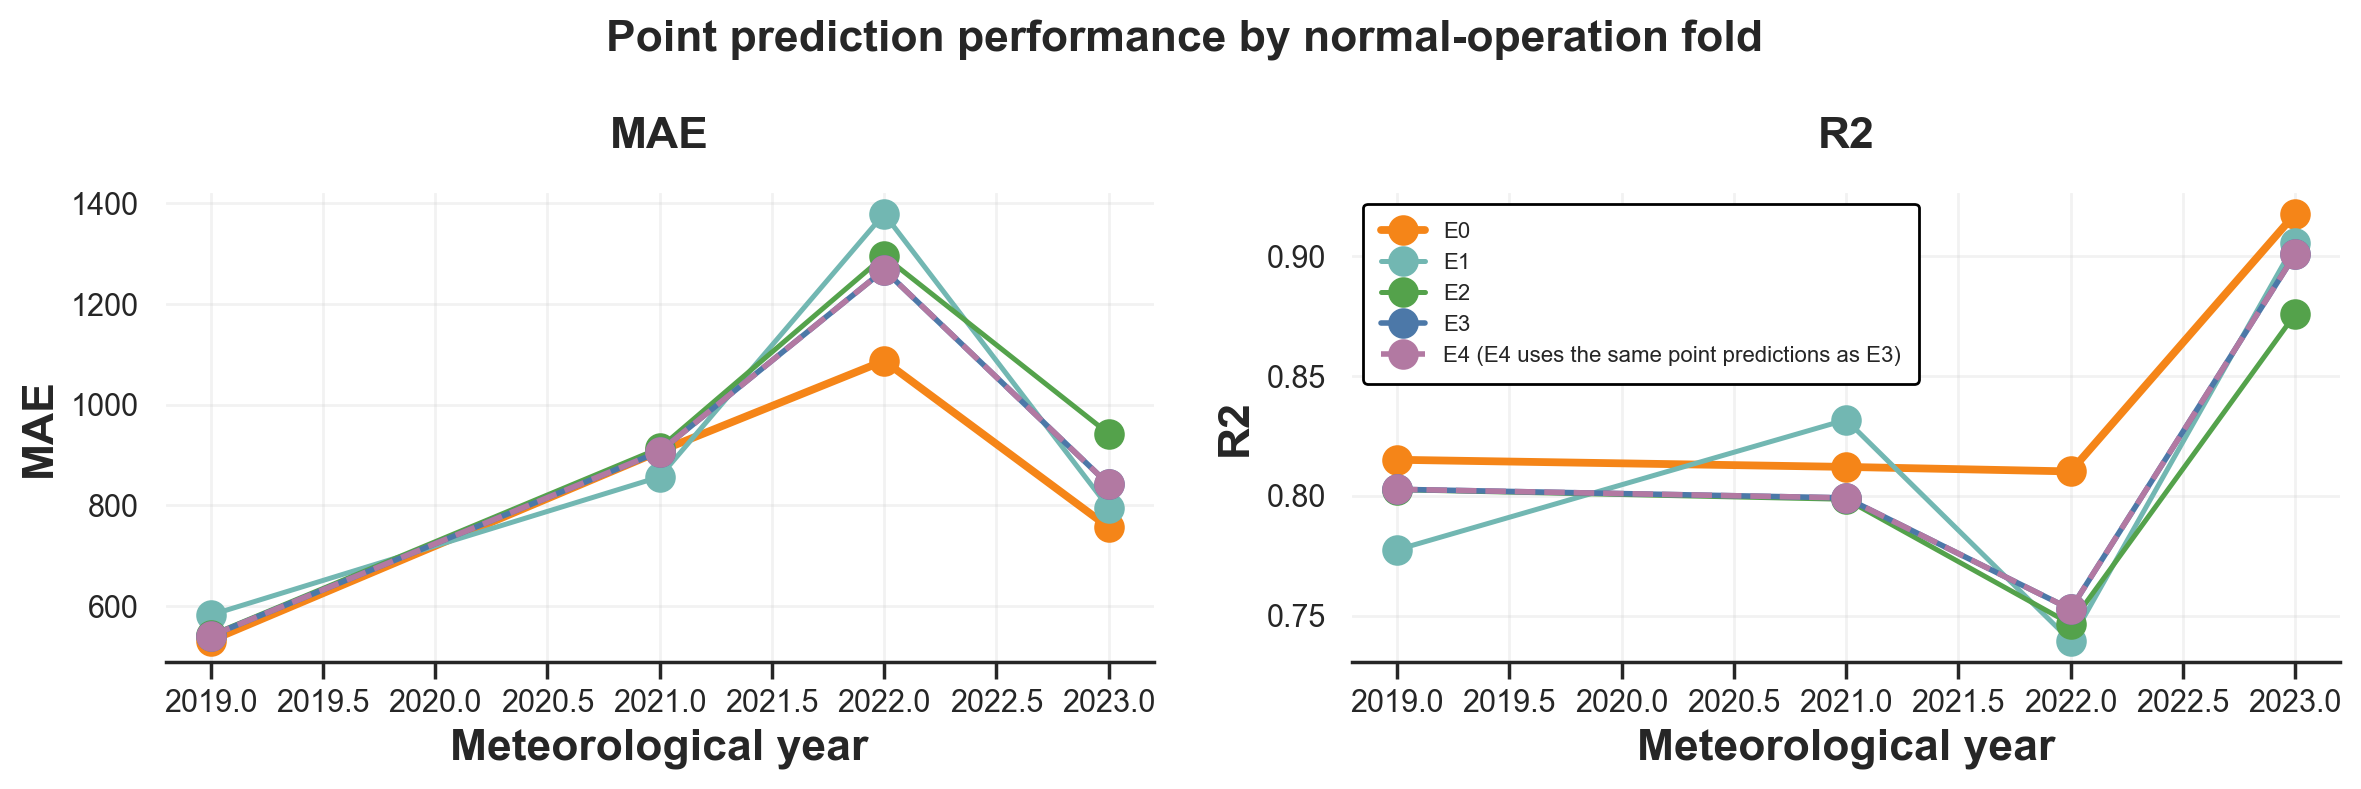

In [9]:
display(reports.experiment_spec_report(results, lang=lang))
display(reports.point_metrics_report(results, lang=lang))
display(reports.plot_point_metrics(results, lang=lang))
reports.plot_point_metrics_by_fold(results, lang=lang)

In [10]:
display(reports.fold_metrics_report(results, lang=lang))
reports.stress_metrics_report(results, lang=lang)

,Experiment,Fold,Meteorological year,Training rows,Excluded training rows,Test rows,Scored normal-operation rows,Selection MAE,Selection RMSE,Selection R2,Selection WAPE,Selection bias
0,E0,1,2019,27689.0,0.0,8715,8715,531.067463,782.778501,0.815006,0.261463,-459.828516
2,E0,3,2021,37196.0,7967.0,8760,8016,907.303424,1252.009734,0.812032,0.282839,-481.345596
3,E0,4,2022,45164.0,8759.0,8759,8759,1086.914530,1724.726290,0.810150,0.245017,-896.080920
4,E0,5,2023,53923.0,8759.0,8760,8760,756.319349,1211.868065,0.917577,0.151479,235.249426
5,E1,1,2019,27689.0,0.0,8715,8715,581.901333,858.542982,0.777462,0.286490,-532.359886
7,E1,3,2021,37196.0,7967.0,8760,8016,856.377030,1184.768351,0.831680,0.266963,-472.652127
8,E1,4,2022,45164.0,8759.0,8759,8759,1378.820715,2020.074509,0.739562,0.310820,-1277.671466
9,E1,5,2023,53923.0,8759.0,8760,8760,795.412803,1298.965166,0.905304,0.159309,341.703300
10,E2,1,2019,27689.0,0.0,8715,8715,541.536780,808.742768,0.802530,0.266617,-495.492906
12,E2,3,2021,37196.0,7967.0,8760,8016,913.268540,1296.243549,0.798516,0.284698,-520.334559


,Experiment,Fold,Meteorological year,Diagnostic rows,Stress MAE,Stress RMSE,Stress R2,Stress WAPE,Stress bias
1,E0,2,2020,8759,1478.114135,2176.171092,-2.355104,1.418034,1438.243498
6,E1,2,2020,8759,1522.167008,2237.553716,-2.547046,1.460296,1475.998350
11,E2,2,2020,8759,1519.623812,2228.619875,-2.518778,1.457857,1483.605478
16,E3,2,2020,8759,1478.043394,2203.179904,-2.438902,1.417966,1422.685655
21,E4,2,2020,8759,1478.043394,2203.179904,-2.438902,1.417966,1422.685655


## 11. Probabilistic Calibration

For E2, E3, and E4, evaluation no longer depends solely on point error. Negative log-likelihood on the logarithmic scale, empirical interval coverage, average width, and the Winkler score are reported. The interpretation follows the distinction among calibration, sharpness, and proper scoring rules discussed by Gneiting, Balabdaoui, and Raftery (2007) and by Gneiting and Raftery (2007).

A model can reduce the ARCH statistic and still produce poorly calibrated intervals. For this reason, nominal versus observed coverage is treated as a diagnostic in its own right.


,Experiment,Observations,Negative log-likelihood,Average width of the 90% interval
0,E2,34250,1.043336,16660.557816
1,E3,34250,1.042262,16432.449429
2,E4,34250,0.945993,4501.534303


,Experiment,Nominal coverage,Observed coverage,Calibration error,Average width,Winkler score
0,E2,0.50,0.892321,0.392321,4817.252538,5017.439425
1,E2,0.80,0.987182,0.187182,11066.014385,11110.072618
2,E2,0.90,0.995562,0.095562,16660.557816,16688.130766
3,E2,0.95,0.997693,0.047693,23331.311183,23352.348683
4,E3,0.50,0.893577,0.393577,4748.895505,4948.652082
5,E3,0.80,0.985927,0.185927,10911.653997,10963.304497
6,E3,0.90,0.994599,0.094599,16432.449429,16472.370015
7,E3,0.95,0.997606,0.047606,23020.183090,23057.495215
8,E4,0.50,0.518920,0.018920,1576.342833,3059.536707
9,E4,0.80,0.724350,-0.075650,3252.445473,4988.585930


,Experiment,Fold,Meteorological year,Nominal coverage,Observed coverage,Calibration error,Average width,Winkler score,Observations
0,E2,1,2019,0.50,0.929317,0.429317,2261.643045,2351.599886,8715
1,E2,3,2021,0.50,0.833084,0.333084,3955.750789,4165.942031,8016
2,E2,4,2022,0.50,0.843818,0.343818,4900.719703,5298.950936,8759
3,E2,5,2023,0.50,0.958219,0.458219,8064.609370,8167.283646,8760
4,E3,1,2019,0.50,0.930924,0.430924,2260.530626,2350.453521,8715
5,E3,3,2021,0.50,0.822106,0.322106,3954.630839,4189.096888,8016
6,E3,4,2022,0.50,0.856947,0.356947,4821.584872,5204.092667,8759
7,E3,5,2023,0.50,0.958447,0.458447,7878.603189,7973.137335,8760
8,E4,1,2019,0.50,0.930924,0.430924,2260.530626,2350.453521,8715
9,E4,3,2021,0.50,0.269586,-0.230414,959.926462,2935.335207,8016


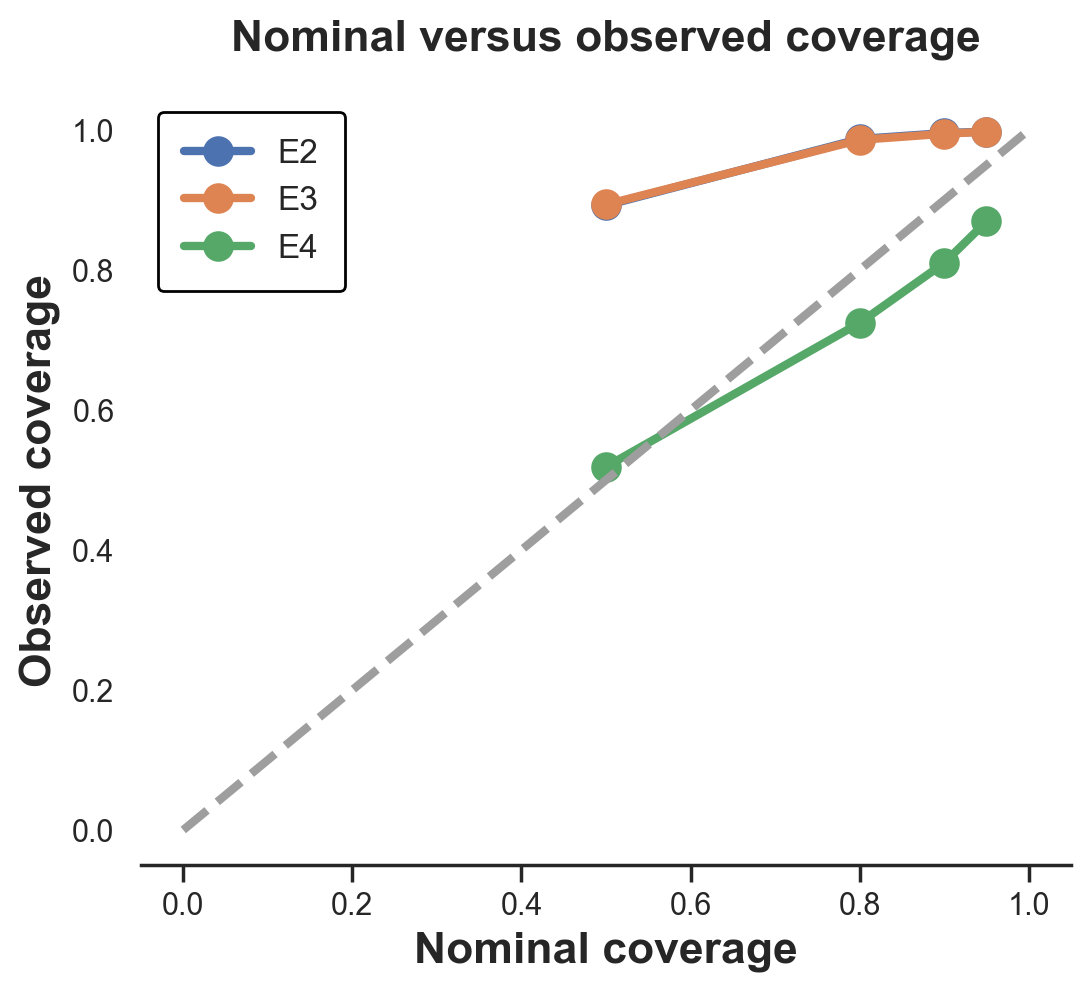

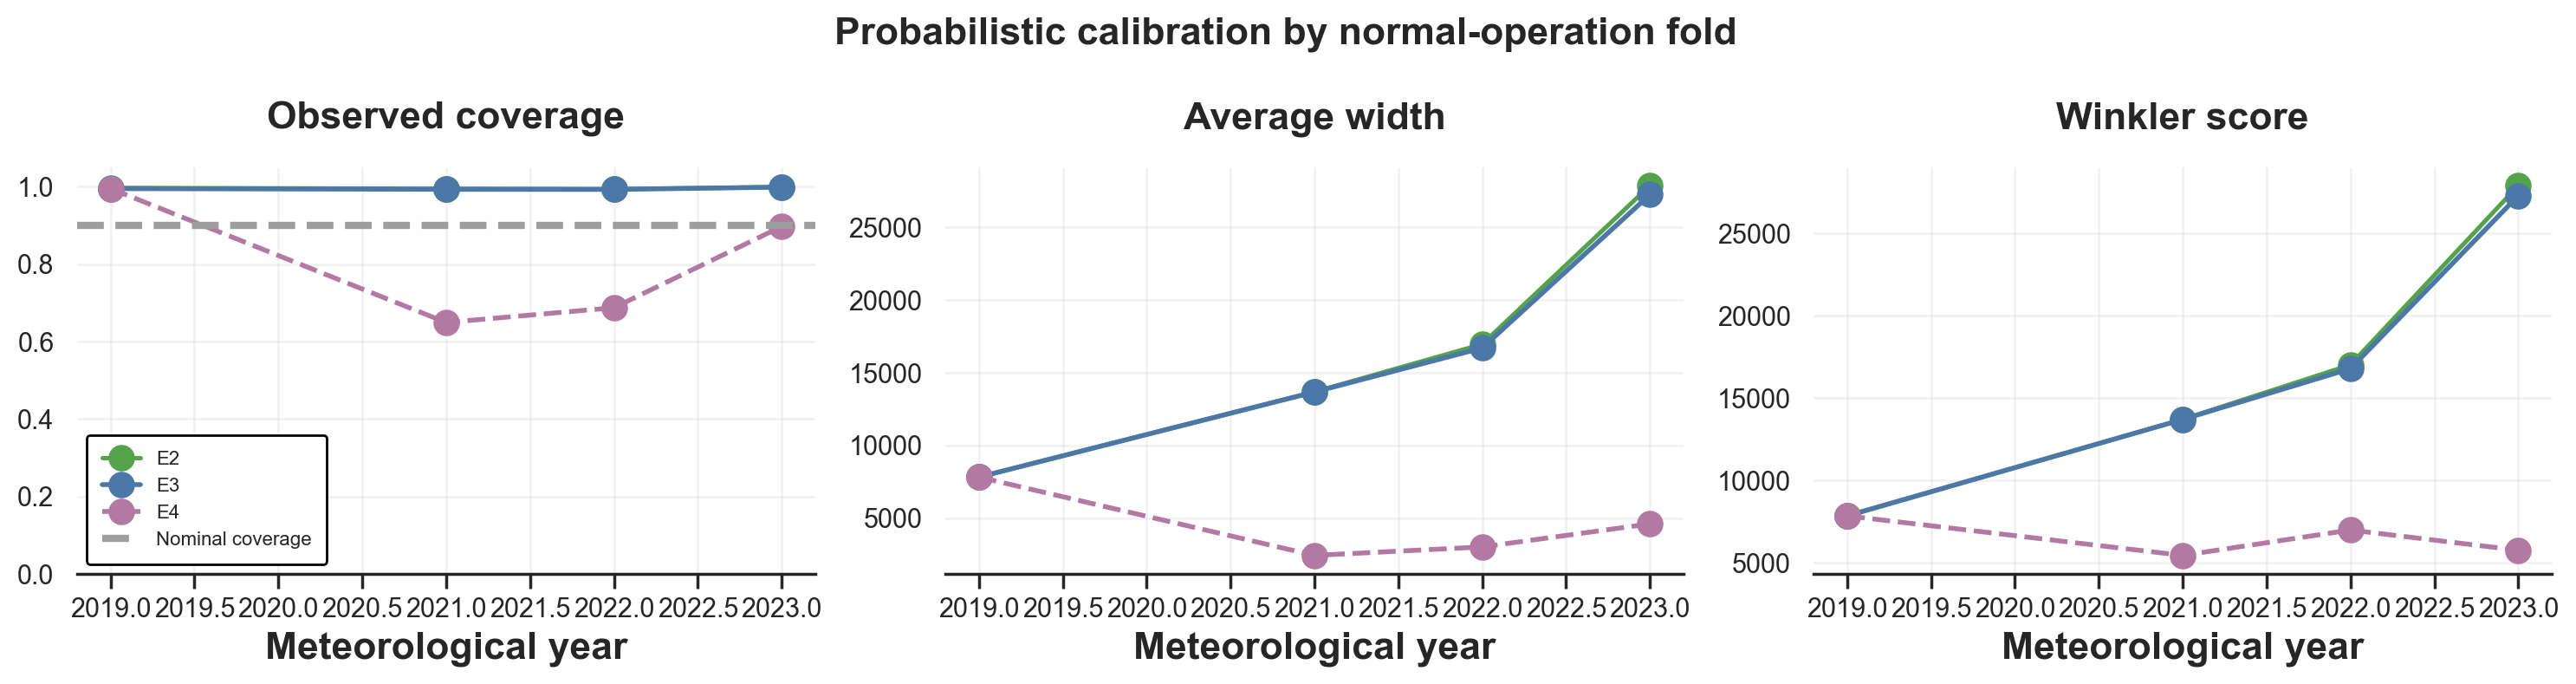

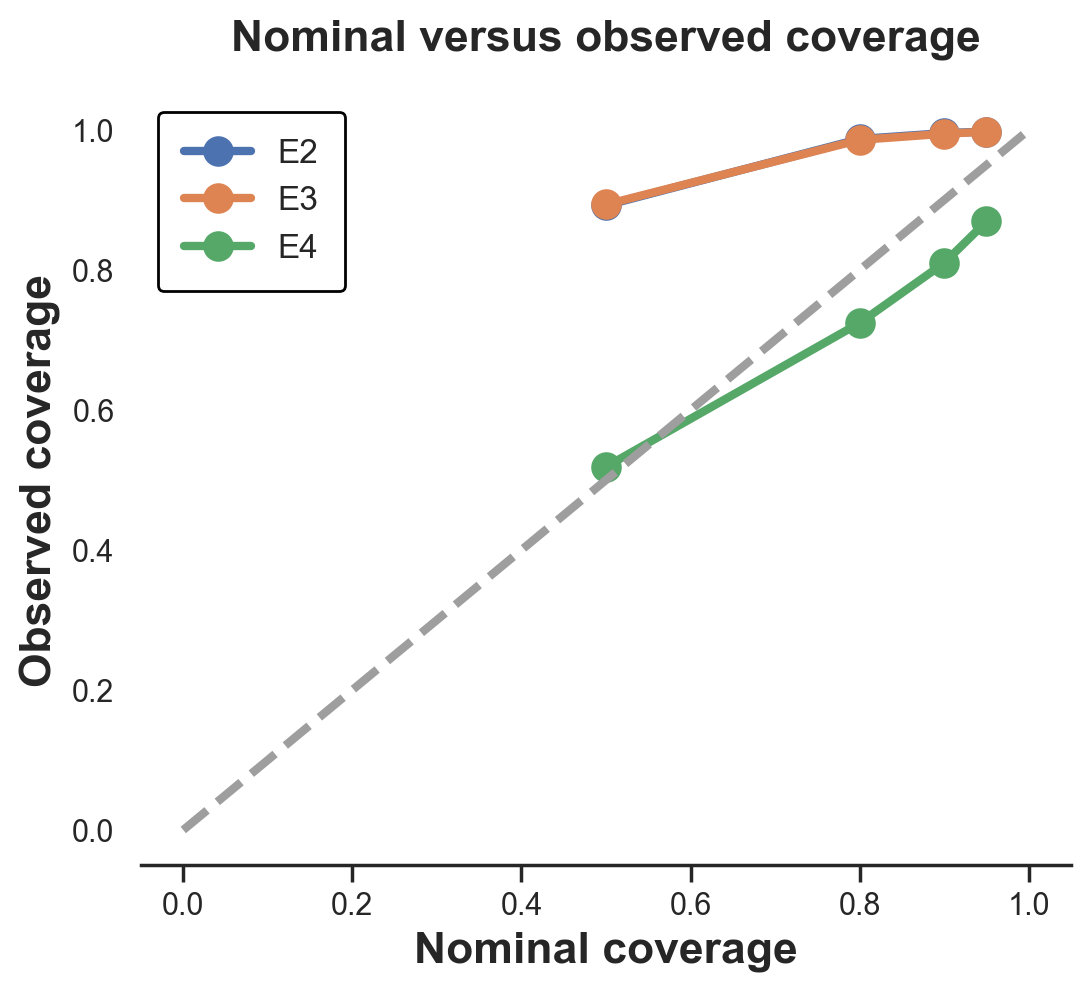

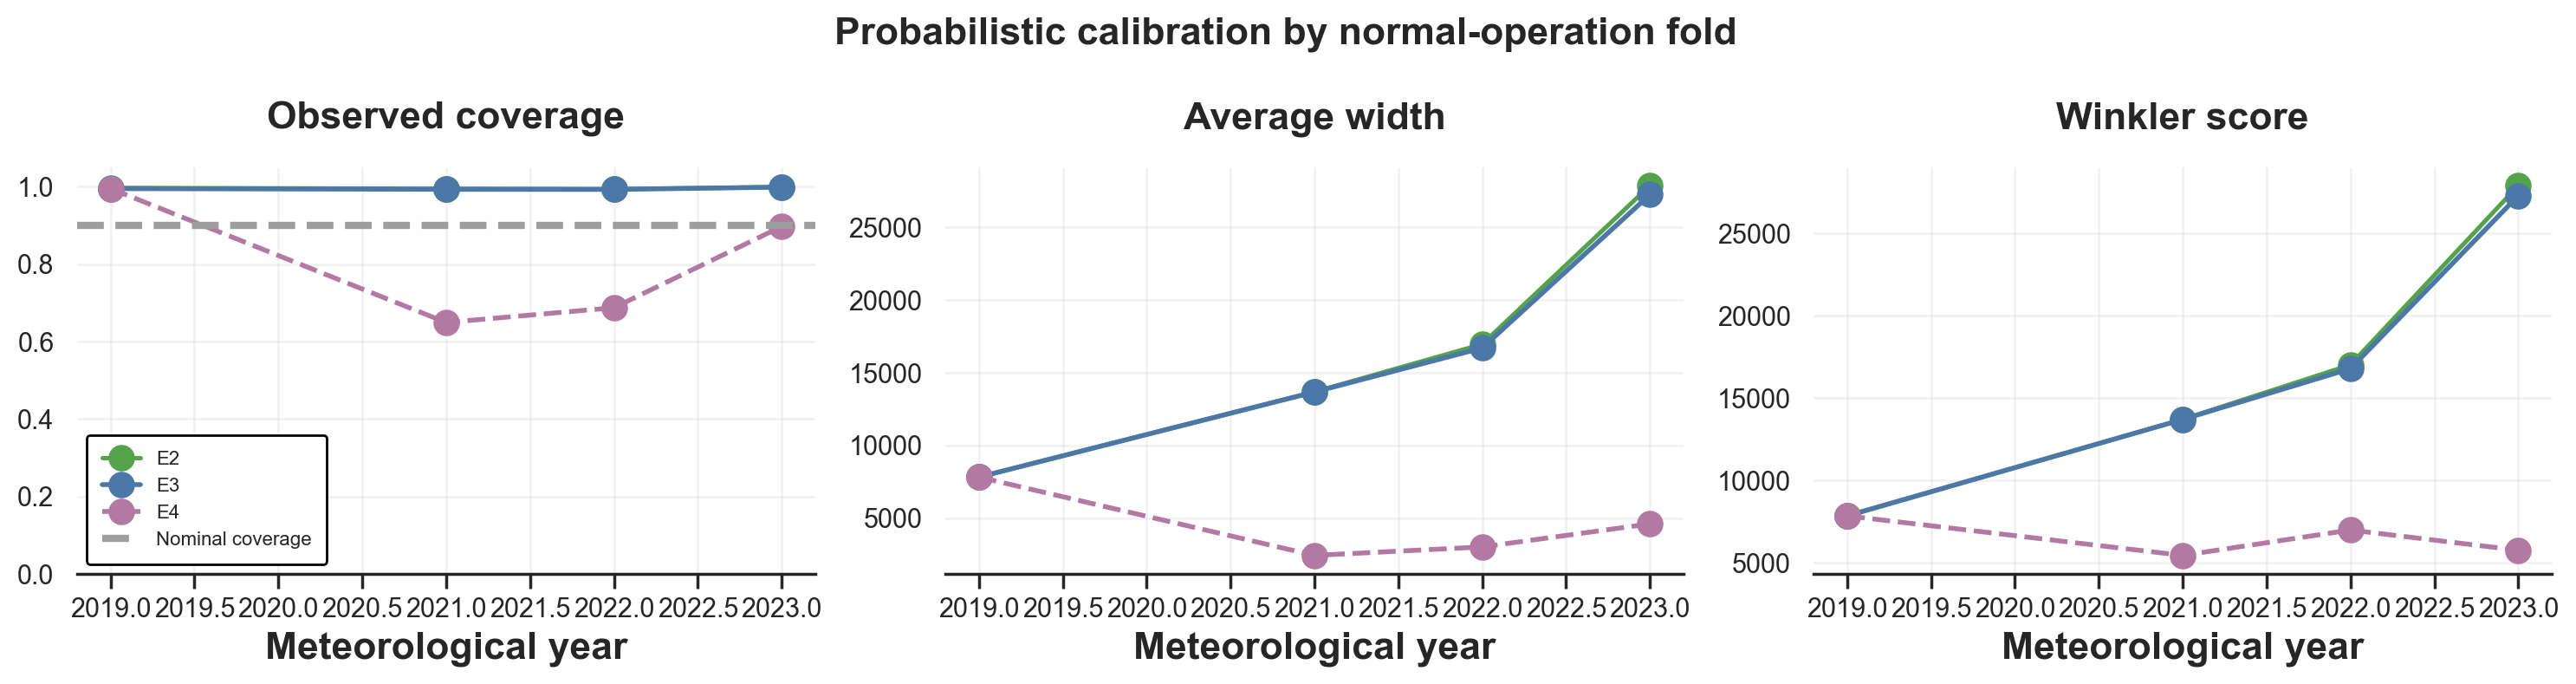

In [11]:
display(reports.probabilistic_metrics_report(results, lang=lang))
display(reports.interval_metrics_report(results, lang=lang))
display(reports.probabilistic_fold_metrics_report(results, lang=lang))
display(reports.plot_coverage_calibration(results, lang=lang))
reports.plot_probabilistic_metrics_by_fold(results, coverage=0.90, lang=lang)

,Experiment,segment,Predicted-demand decile,Observations,MAE,rmse,r2,wape,mean_bias,90% coverage,Average 90% width
56,E2,predicted_demand_decile,0,3425,172.802682,351.051150,-0.016870,0.497707,-115.523809,0.976934,1366.535993
57,E2,predicted_demand_decile,1,3425,273.969805,469.397242,-0.093591,0.403249,-165.768845,0.994161,2840.213754
58,E2,predicted_demand_decile,2,3425,367.802365,554.145723,-0.088574,0.360332,-195.377194,0.994453,4398.516008
59,E2,predicted_demand_decile,3,3425,571.914809,828.577554,-0.148250,0.356820,-350.018477,0.996496,6550.473525
60,E2,predicted_demand_decile,4,3425,737.253272,1015.070022,-0.216458,0.323509,-481.764048,0.997956,9270.731527
61,E2,predicted_demand_decile,5,3425,963.381682,1293.890952,-0.274222,0.309256,-646.343832,0.998832,12640.728540
62,E2,predicted_demand_decile,6,3425,1212.030128,1635.134257,-0.235910,0.290244,-795.732160,0.999416,17209.024116
63,E2,predicted_demand_decile,7,3425,1341.056944,1804.981555,-0.223974,0.247536,-866.899923,0.999708,23066.390013
64,E2,predicted_demand_decile,8,3425,1562.862378,2130.191199,-0.057312,0.217351,-758.284915,0.998248,32498.427362
65,E2,predicted_demand_decile,9,3425,2033.430475,2627.739201,0.425228,0.185487,315.776746,0.999416,56764.537324


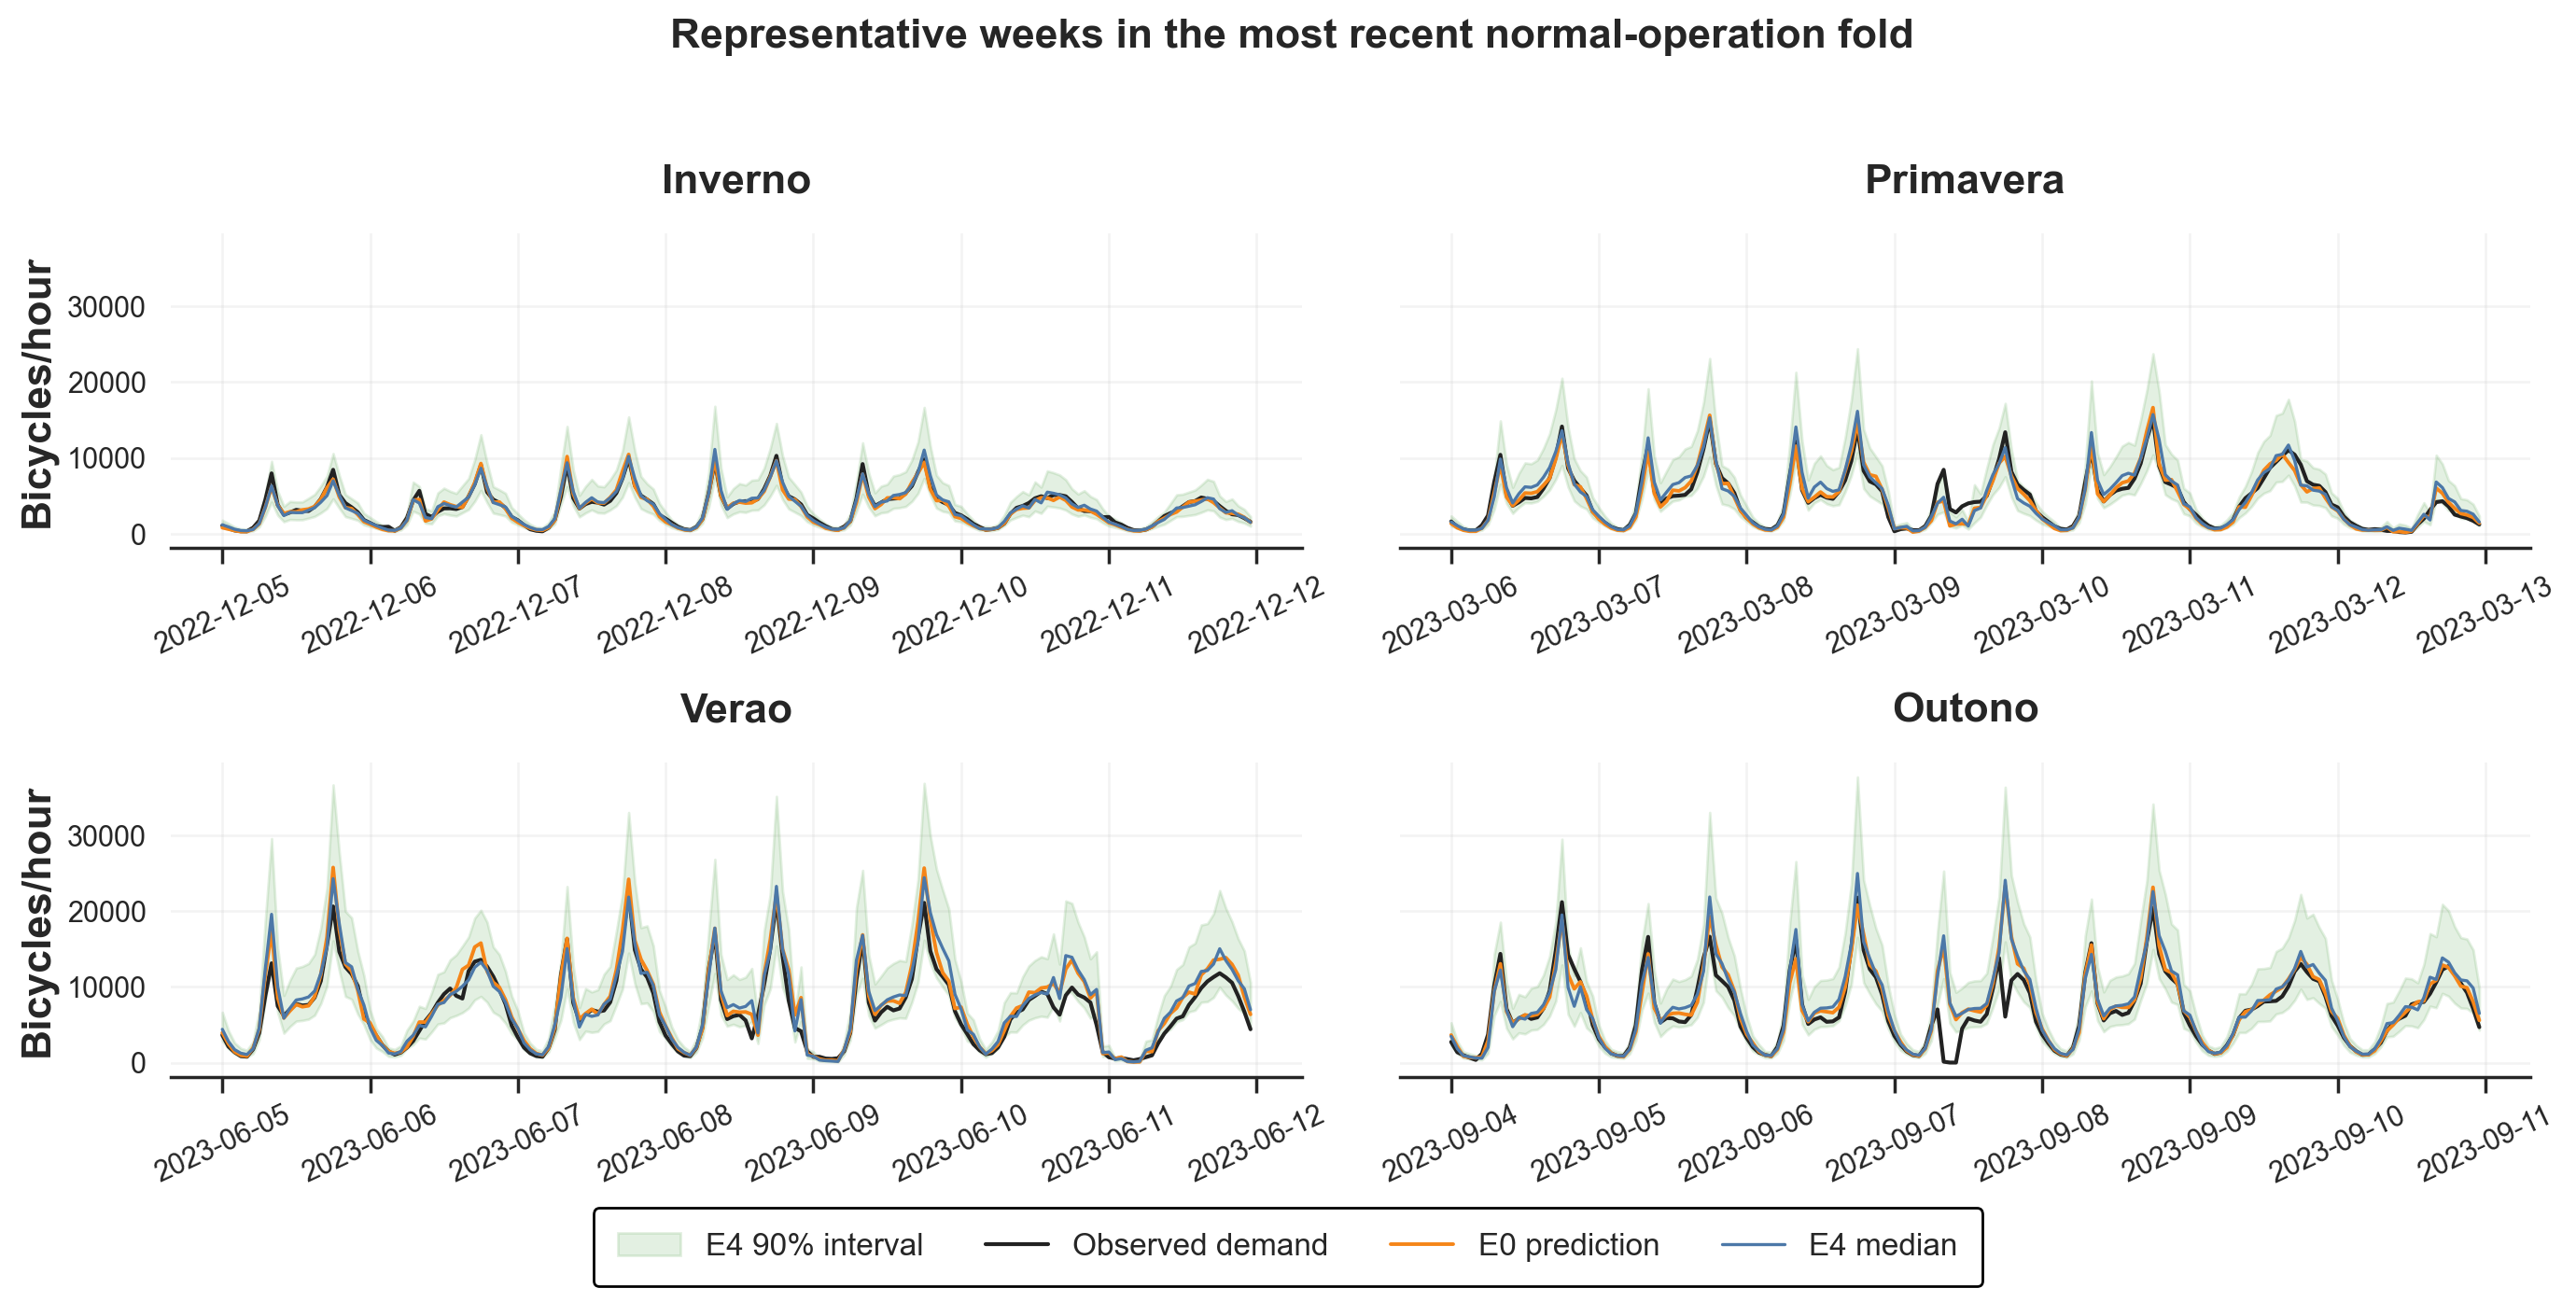

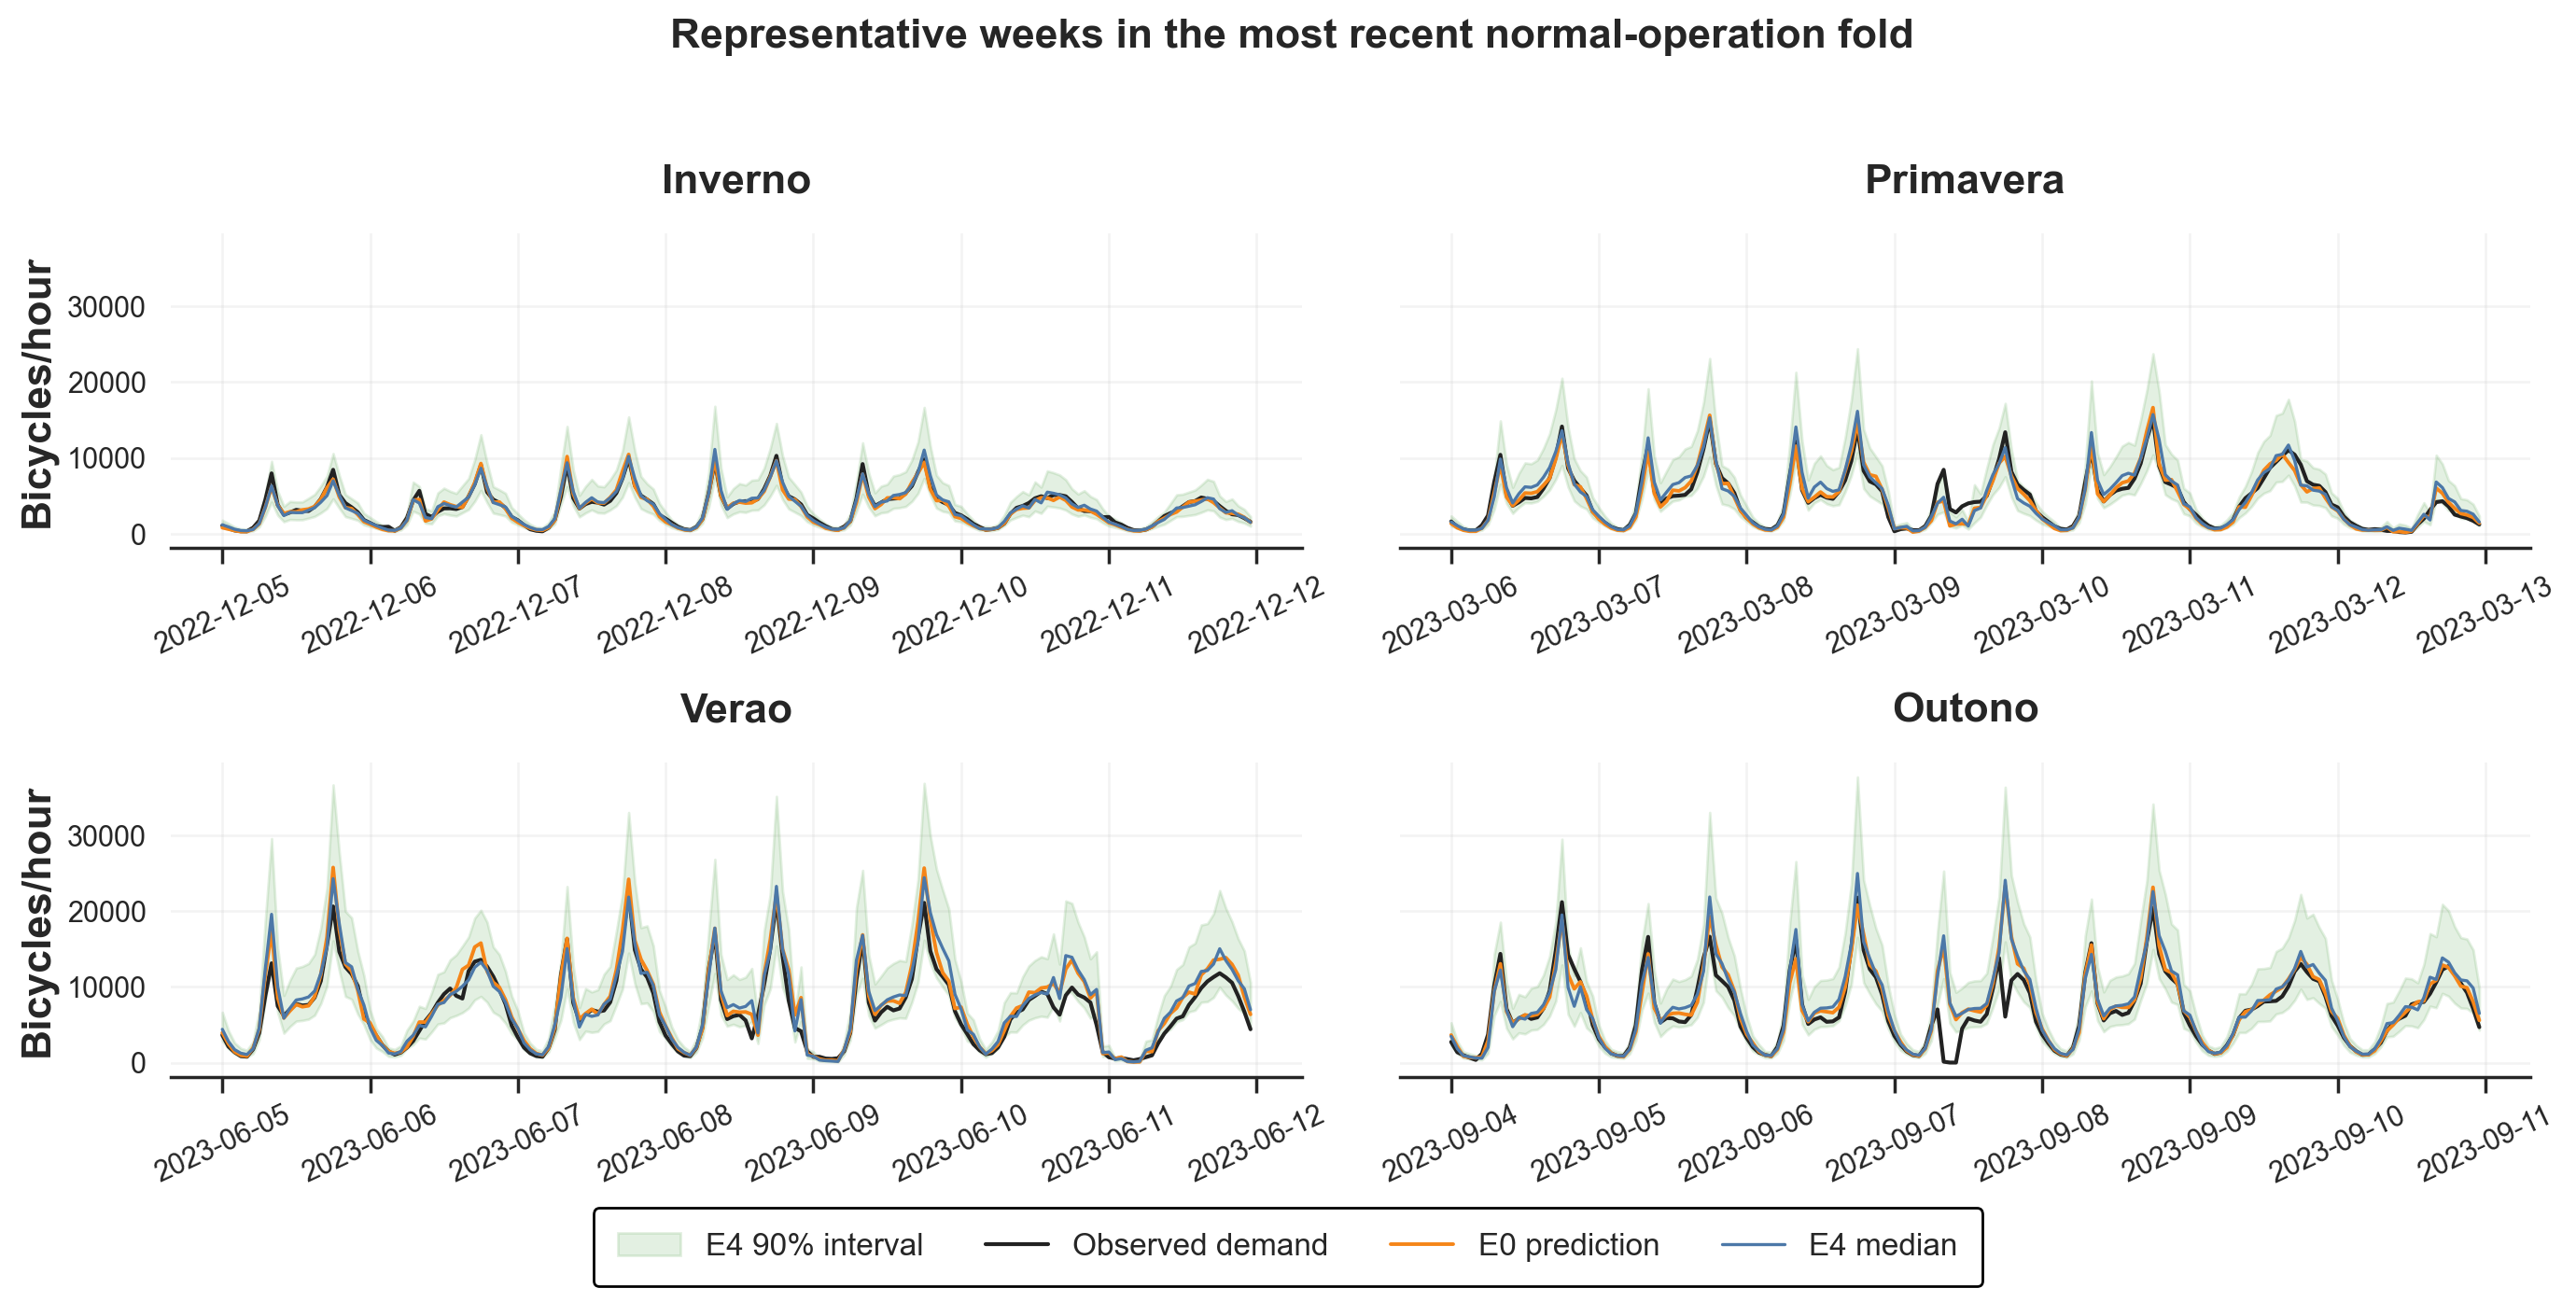

In [12]:
display(reports.interval_width_report(results, lang=lang))
reports.plot_representative_interval_windows(results, lang=lang)

## 12. Ablation and Stability

The residual structure is audited through residual autocorrelation, squared-residual autocorrelation, and ARCH statistics normalized by observation count. These measures do not replace MAE and R², but indicate whether conditional variance remains clustered over time, as in the classical problem of conditional heteroscedasticity formalized by Engle (1982).

The ablation compares E1, E2, and E3 against E0 and compares E4 against E3. This separates the effects of the features, probabilistic loss, and residual-scale layer.


,Experiment,Observations,Residual ACF at lag 1,Squared-residual ACF at lag 1,Residual ACF at lag 24,Squared-residual ACF at lag 24,Residual ACF at lag 168,Squared-residual ACF at lag 168,ARCH per observation at lag 24,ARCH per observation at lag 168
0,E0,34250,0.783941,0.517433,0.625628,0.484679,0.595075,0.501808,0.432036,0.508025
1,E1,34250,0.793152,0.541511,0.656899,0.511233,0.637579,0.507858,0.469560,0.542626
2,E2,34250,0.791136,0.558395,0.650768,0.502358,0.636992,0.520401,0.463573,0.538801
3,E3,34250,0.761792,0.533954,0.623615,0.495378,0.623066,0.529567,0.451833,0.534388
4,E4,34250,0.761792,0.533954,0.623615,0.495378,0.623066,0.529567,0.451833,0.534388


,Experiment,Fold,Meteorological year,Observations,Fallback rate,Rate at the floor,P10,P25,Median,P75,P90
0,E4,1,2019,8715,1.000000,0.000000,1.00,1.00,1.00,1.000000,1.000000
1,E4,3,2021,8016,0.020958,0.819736,0.25,0.25,0.25,0.250000,0.296377
2,E4,4,2022,8759,0.000343,0.732504,0.25,0.25,0.25,0.258335,0.360567
3,E4,5,2023,8760,0.000000,0.972717,0.25,0.25,0.25,0.250000,0.250000


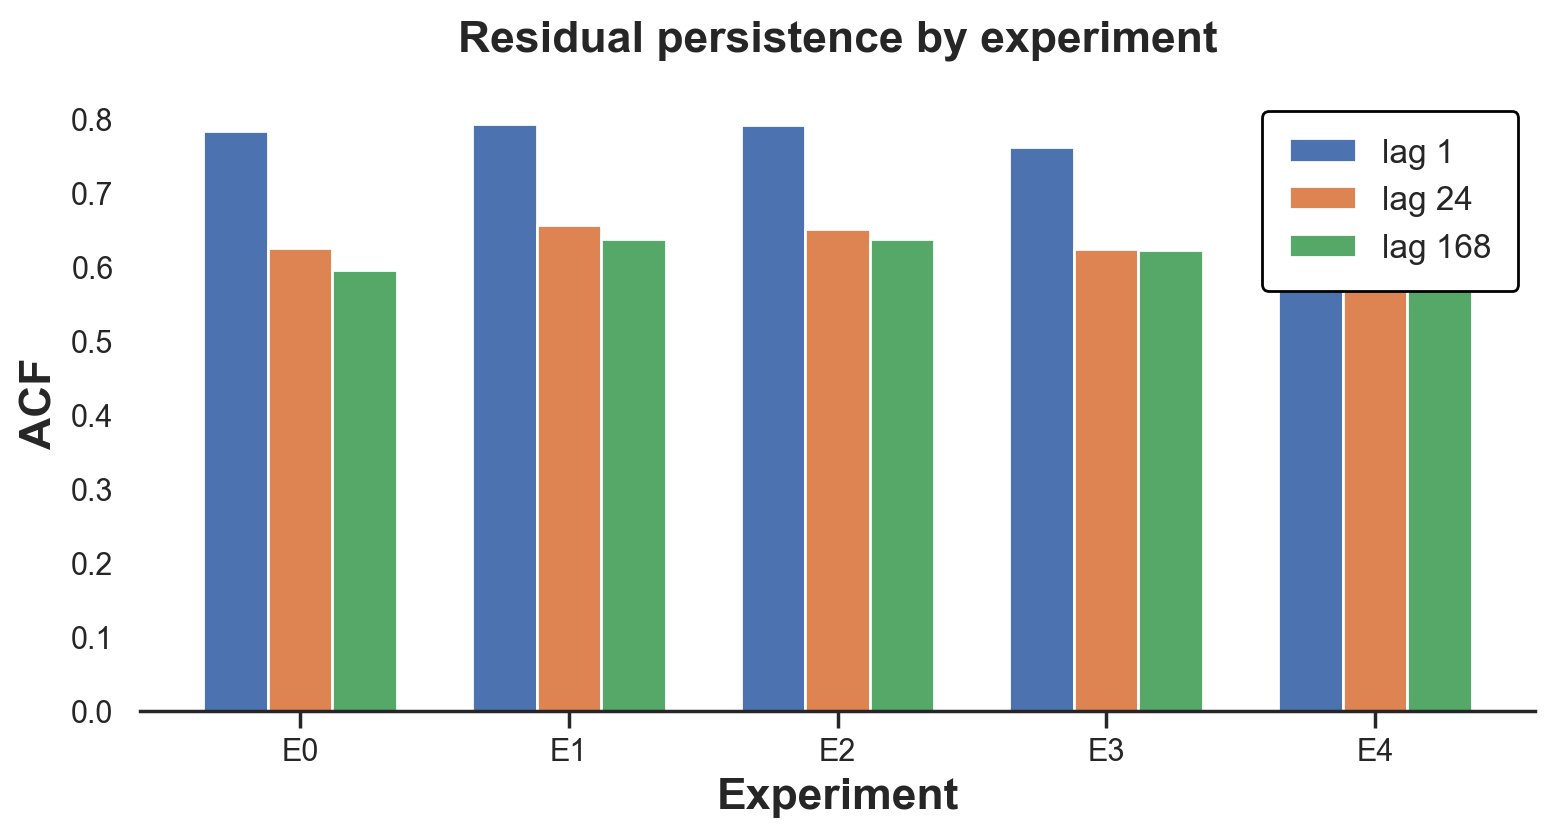

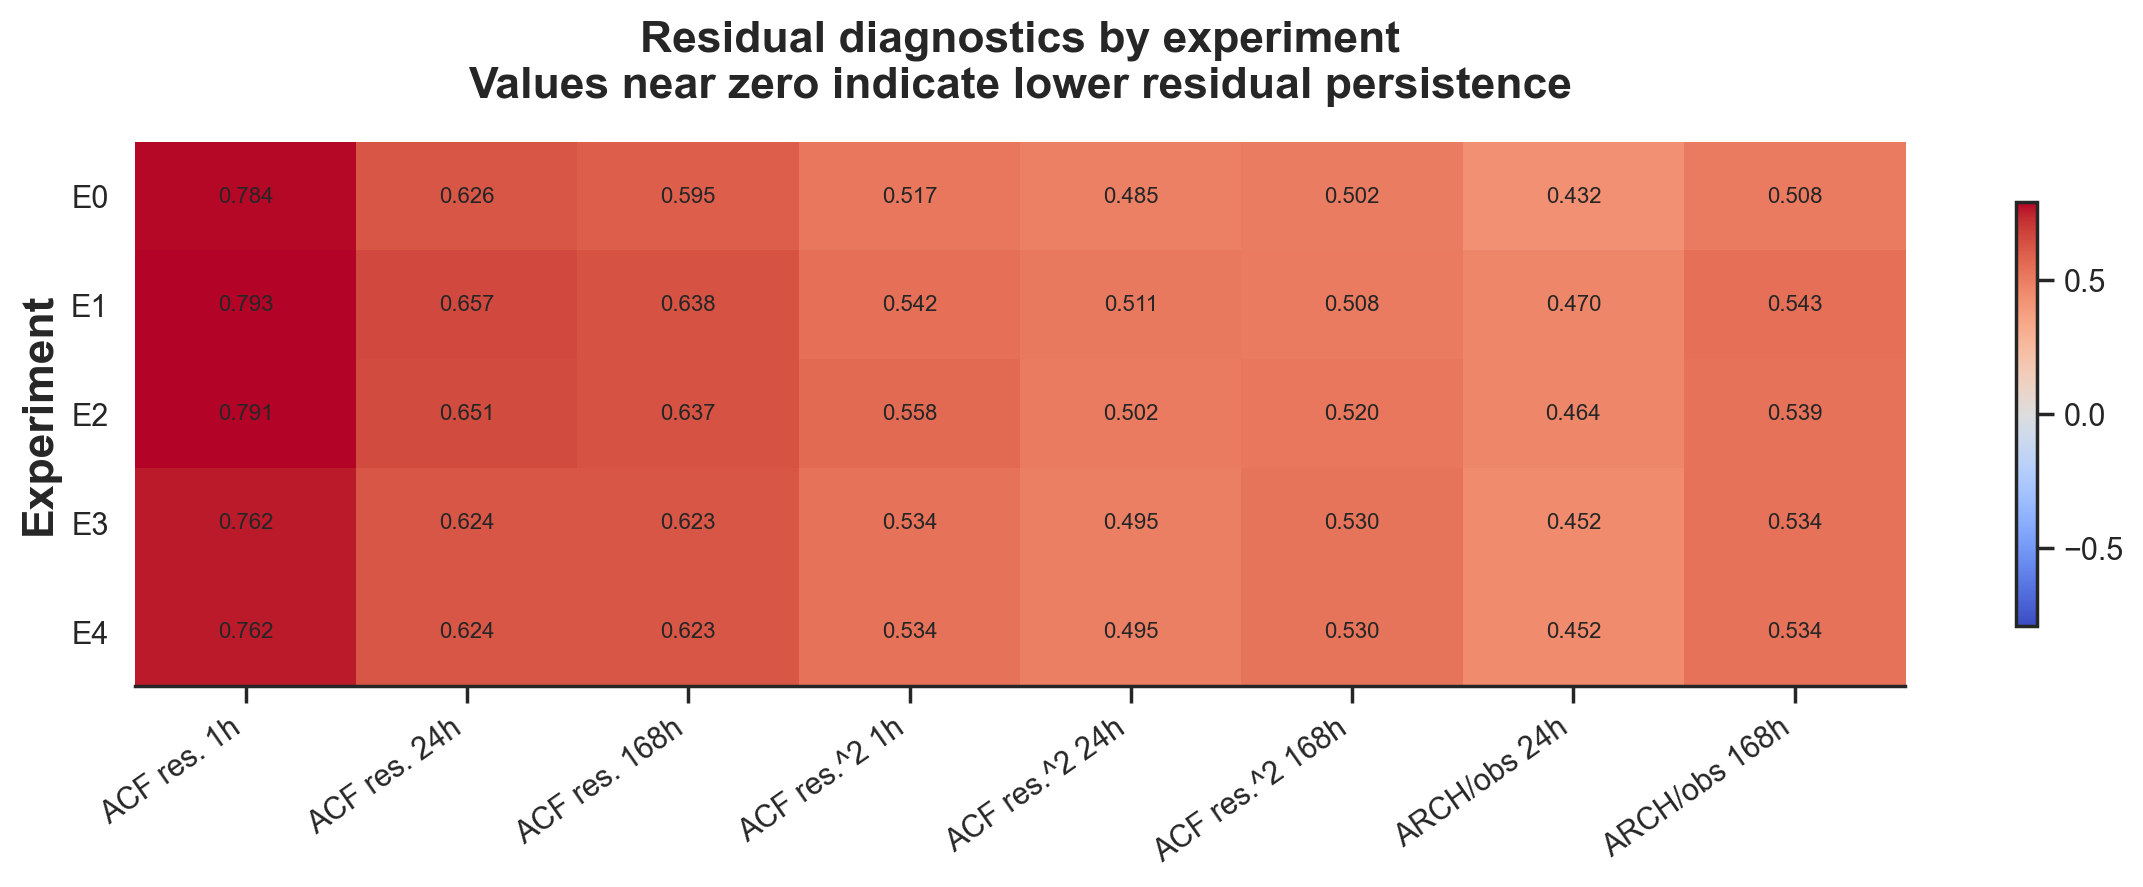

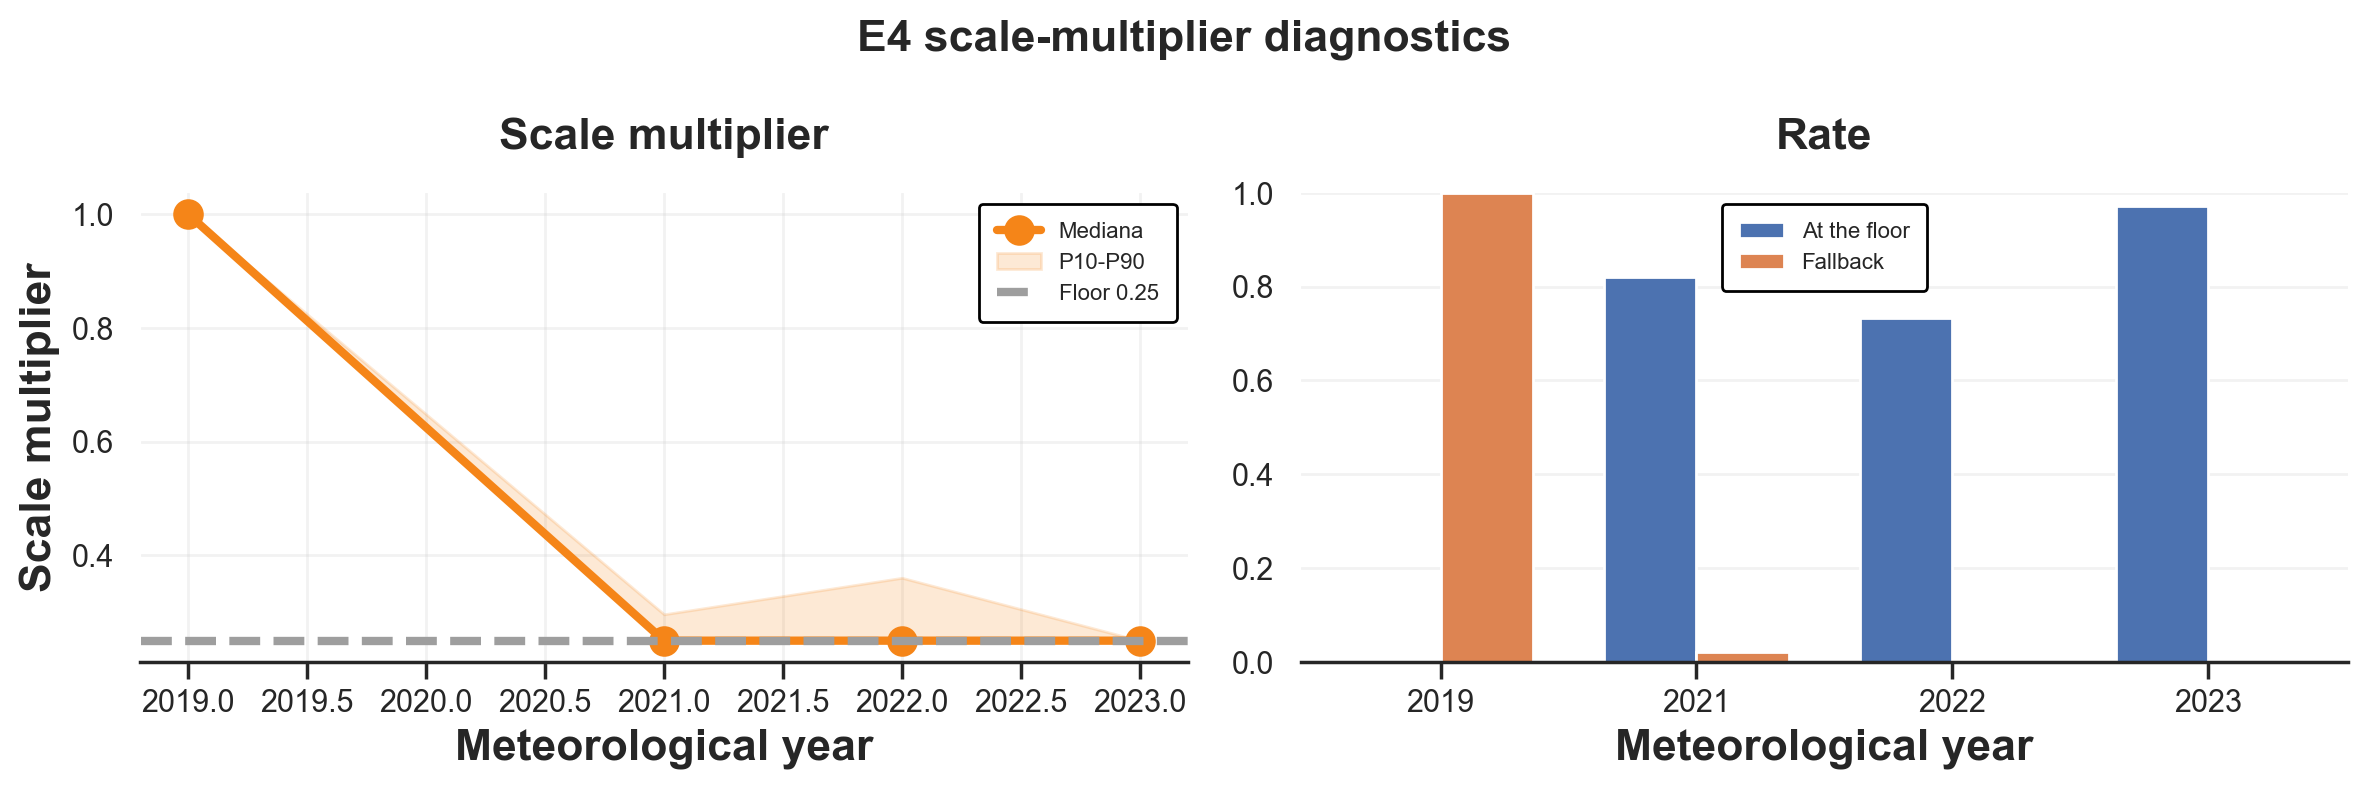

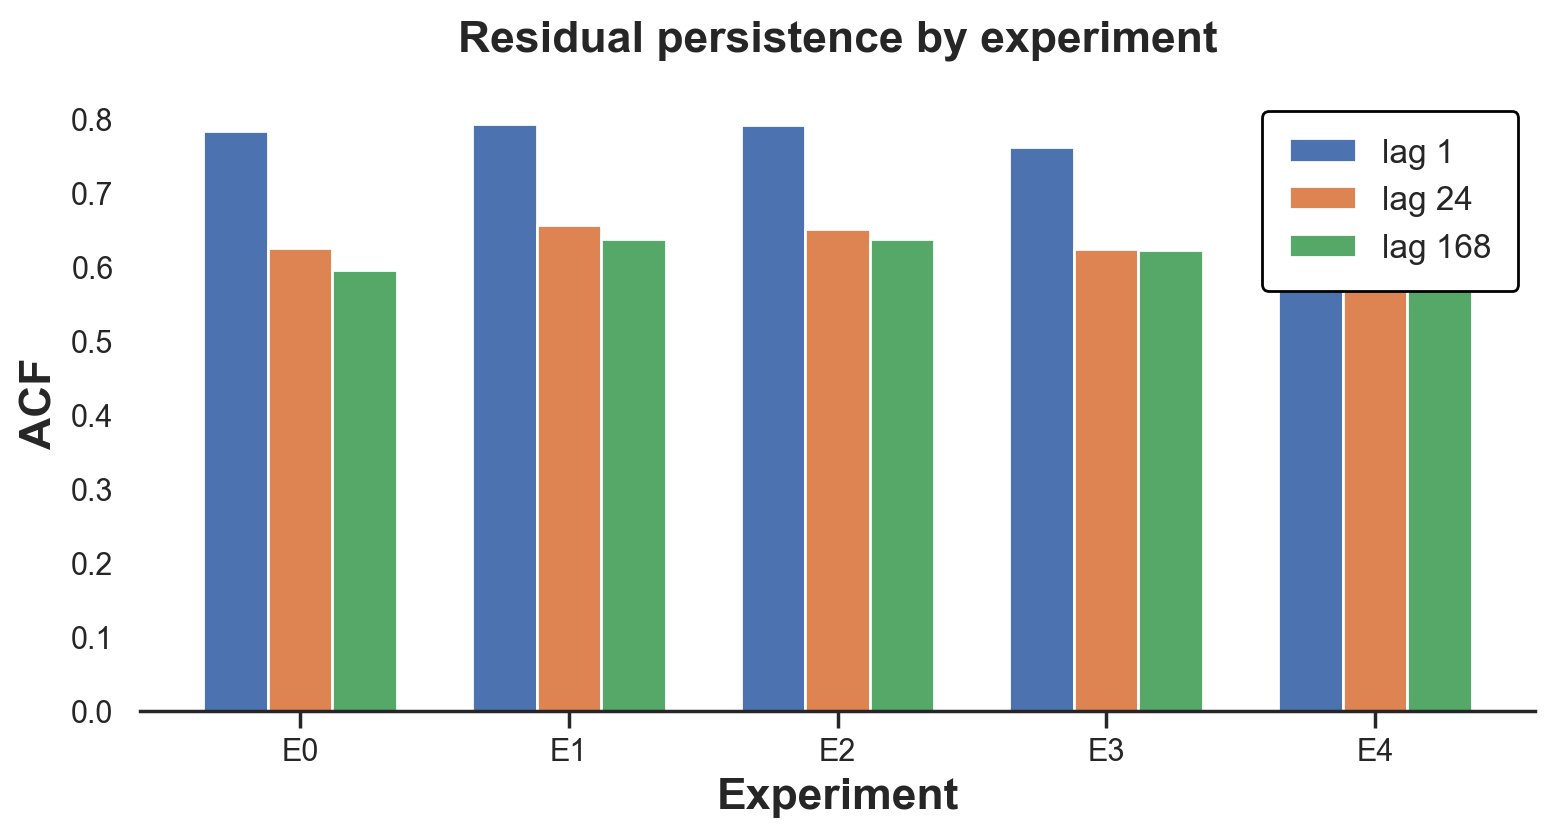

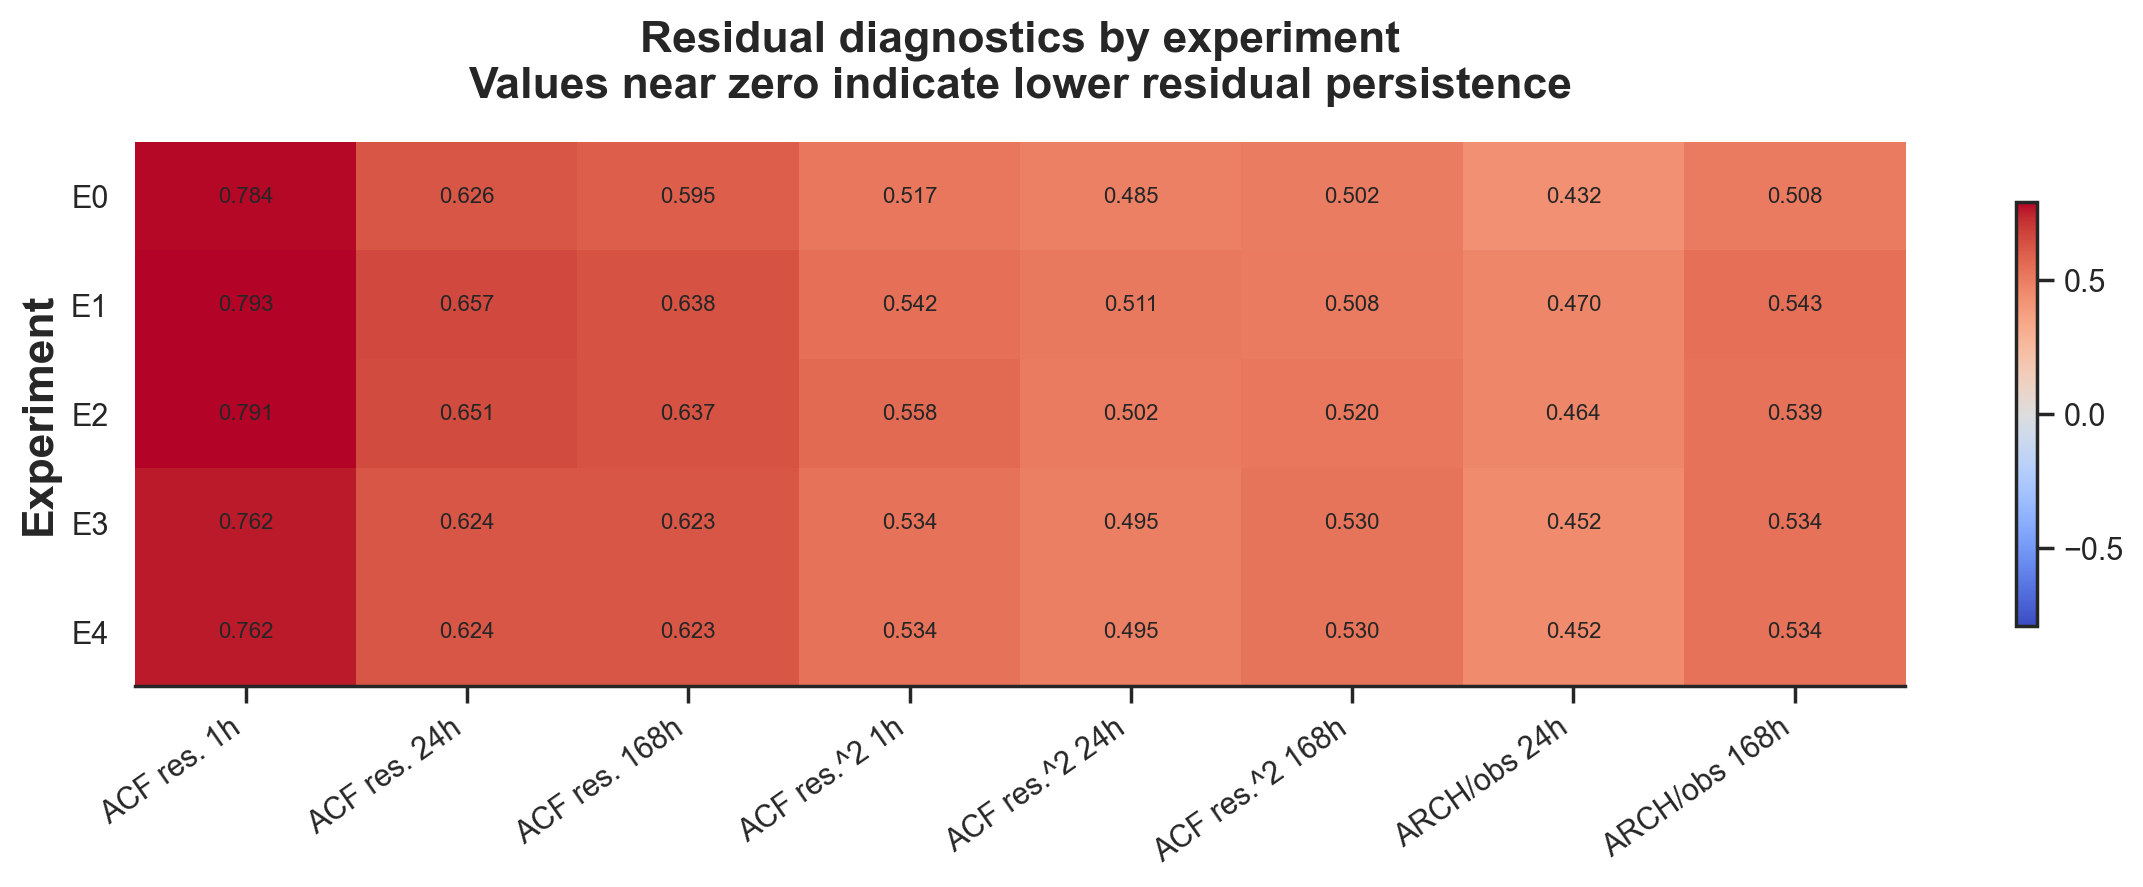

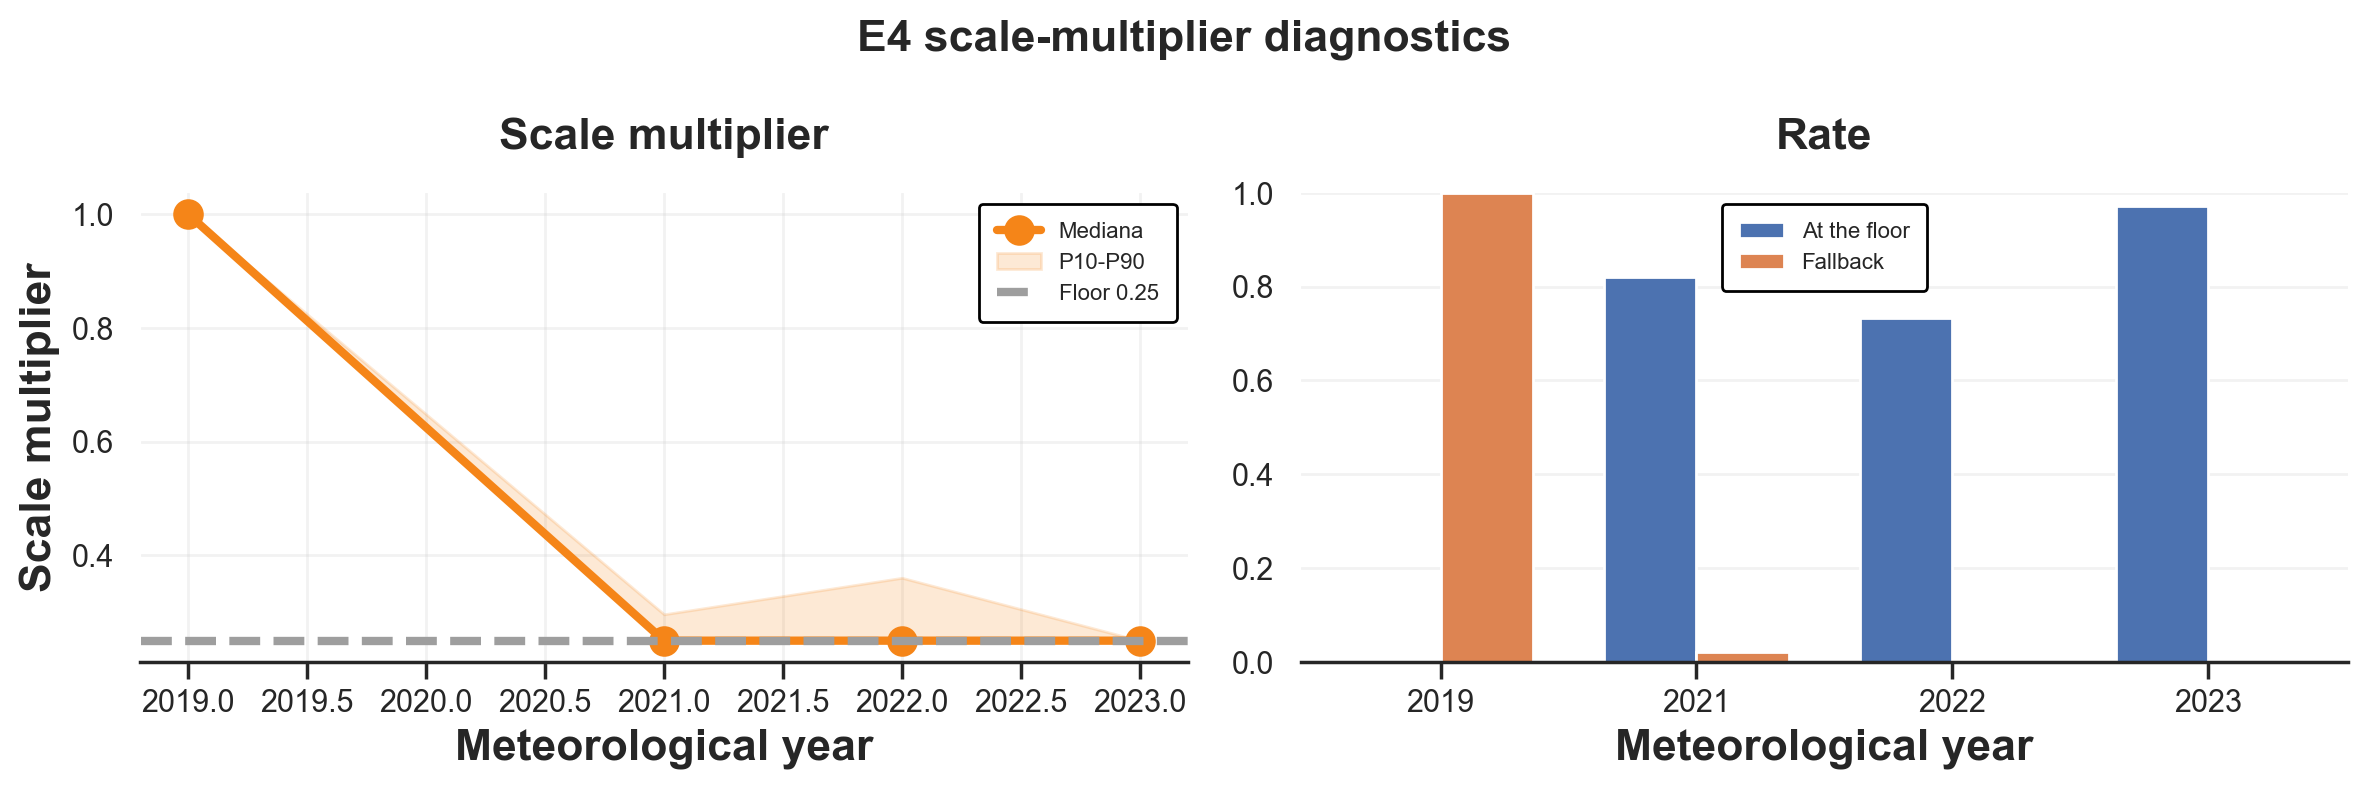

In [13]:
display(reports.residual_dependence_report(results, lang=lang))
display(reports.scale_diagnostics_report(results, lang=lang))
display(reports.plot_residual_dependence(results, lang=lang))
display(reports.plot_residual_diagnostics_heatmap(results, lang=lang))
reports.plot_scale_diagnostics(results, lang=lang)

In [14]:
reports.ablation_report(results, lang=lang)

,Experiment,Reference,Weighted MAE delta,Weighted R2 delta
0,E1,E0,100.142887,-0.027985
1,E2,E0,141.414019,-0.039819
2,E3,E0,89.306232,-0.027251
3,E4,E3,0.000000,0.000000


## 13. Experimental Decision and Segments

Friday at 6 PM was previously motivated by the residuals of the final validation and continues to be monitored as a stress segment, not as an isolated criterion for choice. Metrics are also verified for rush period, season, rain, and forecasted demand level, because the probabilistic undercoverage may be concentrated in specific operational regimes.

The experimental decision was separated into two layers. The point successor would only be considered if MAE and R² were improved in the normal selection folds. The uncertainty layer would only be considered as a probabilistic hypothesis if the empirical coverage, width, and Winkler score were defensible without reopening the holdout.


,Experiment,Segment,Value,Observations,MAE,rmse,R2,wape,Mean bias,90% coverage,Average 90% width
0,E0,Rush_Period,Evening Rush,3876,1498.923348,2120.534999,0.824642,0.198607,-811.092424,NaN,NaN
1,E0,Rush_Period,Morning Rush,2910,1324.147785,1985.300369,0.748503,0.240824,-897.677800,NaN,NaN
2,E0,Rush_Period,Non-Rush,27464,669.375987,1008.396147,0.865101,0.227647,-287.570018,NaN,NaN
22,E1,Rush_Period,Evening Rush,3876,1703.802306,2372.042799,0.780579,0.225753,-1015.529084,NaN,NaN
23,E1,Rush_Period,Morning Rush,2910,1491.317499,2178.133845,0.697274,0.271227,-1007.473935,NaN,NaN
24,E1,Rush_Period,Non-Rush,27464,729.581399,1089.246672,0.842602,0.248122,-355.307291,NaN,NaN
44,E2,Rush_Period,Evening Rush,3876,1754.239996,2485.962006,0.758997,0.232436,-916.237435,0.995872,33651.182920
45,E2,Rush_Period,Morning Rush,2910,1427.691602,2141.783292,0.707294,0.259655,-787.922449,0.994502,24175.125324
46,E2,Rush_Period,Non-Rush,27464,753.022548,1145.658906,0.825877,0.256094,-293.514846,0.995631,13466.447186
66,E3,Rush_Period,Evening Rush,3876,1648.873330,2384.009678,0.778359,0.218475,-1025.974813,0.994582,33107.628303


,Experiment,Segment,Value,Observations,MAE,rmse,R2,wape,Mean bias,90% coverage,Average 90% width
3,E0,Seasons,Autumn,8691,1171.376300,1773.803416,0.786246,0.263590,-885.148521,NaN,NaN
4,E0,Seasons,Spring,8832,741.801805,1130.671030,0.906014,0.185260,-251.090571,NaN,NaN
5,E0,Seasons,Summer,8831,998.018113,1349.694726,0.867213,0.221739,-312.314382,NaN,NaN
6,E0,Seasons,Winter,7896,316.782690,516.000108,0.881880,0.203769,-124.791488,NaN,NaN
25,E1,Seasons,Autumn,8691,1211.702054,1834.203842,0.771441,0.272664,-943.112149,NaN,NaN
26,E1,Seasons,Spring,8832,955.661171,1466.332752,0.841928,0.238670,-451.872230,NaN,NaN
27,E1,Seasons,Summer,8831,1047.335742,1410.411468,0.854997,0.232697,-358.924509,NaN,NaN
28,E1,Seasons,Winter,7896,349.616419,551.670662,0.864985,0.224889,-160.703364,NaN,NaN
47,E2,Seasons,Autumn,8691,1258.351303,1921.879069,0.749068,0.283162,-956.431056,0.995282,17777.521790
48,E2,Seasons,Spring,8832,910.376638,1396.539595,0.856618,0.227361,-271.679566,0.996037,18923.967253


,Experiment,Segment,Value,Observations,MAE,rmse,R2,wape,Mean bias,90% coverage,Average 90% width
7,E0,Rainfall Cat,Heavy Rain,191,434.056049,1050.097731,0.242539,0.708933,-349.421412,NaN,NaN
8,E0,Rainfall Cat,Light Rain,1558,655.092371,1135.427407,0.459152,0.566126,-317.313675,NaN,NaN
9,E0,Rainfall Cat,Moderate Rain,360,321.010858,742.713145,0.610918,0.576983,-173.178023,NaN,NaN
10,E0,Rainfall Cat,No Rain,32141,834.688918,1301.072656,0.868555,0.216547,-405.413688,NaN,NaN
29,E1,Rainfall Cat,Heavy Rain,191,464.360765,1090.041936,0.183817,0.758429,-314.573503,NaN,NaN
30,E1,Rainfall Cat,Light Rain,1558,671.509044,1151.458406,0.443772,0.580313,-340.267443,NaN,NaN
31,E1,Rainfall Cat,Moderate Rain,360,381.232440,948.865004,0.364951,0.685225,-115.982799,NaN,NaN
32,E1,Rainfall Cat,No Rain,32141,924.325550,1428.448687,0.841558,0.239802,-497.623761,NaN,NaN
51,E2,Rainfall Cat,Heavy Rain,191,446.112134,1043.876752,0.251487,0.728623,-297.977924,0.905759,2258.532060
52,E2,Rainfall Cat,Light Rain,1558,657.466409,1125.390322,0.468672,0.568177,-343.918612,0.967908,5368.228501


,Experiment,Segment,Observations,MAE,RMSE,R2,wape,Mean bias
0,E0,Friday 18h,203,1878.767604,2466.476500,0.826522,0.183097,-851.915697
1,E1,Friday 18h,203,2153.950838,2820.065486,0.773218,0.209915,-1148.243147
2,E2,Friday 18h,203,2002.750803,2688.336915,0.793910,0.195180,-682.408677
3,E3,Friday 18h,203,1892.791097,2612.038182,0.805442,0.184464,-850.849699
4,E4,Friday 18h,203,1892.791097,2612.038182,0.805442,0.184464,-850.849699


2026-08-03 22:59:36,887 — matplotlib.category — INFO — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-08-03 22:59:36,887 — matplotlib.category — INFO — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


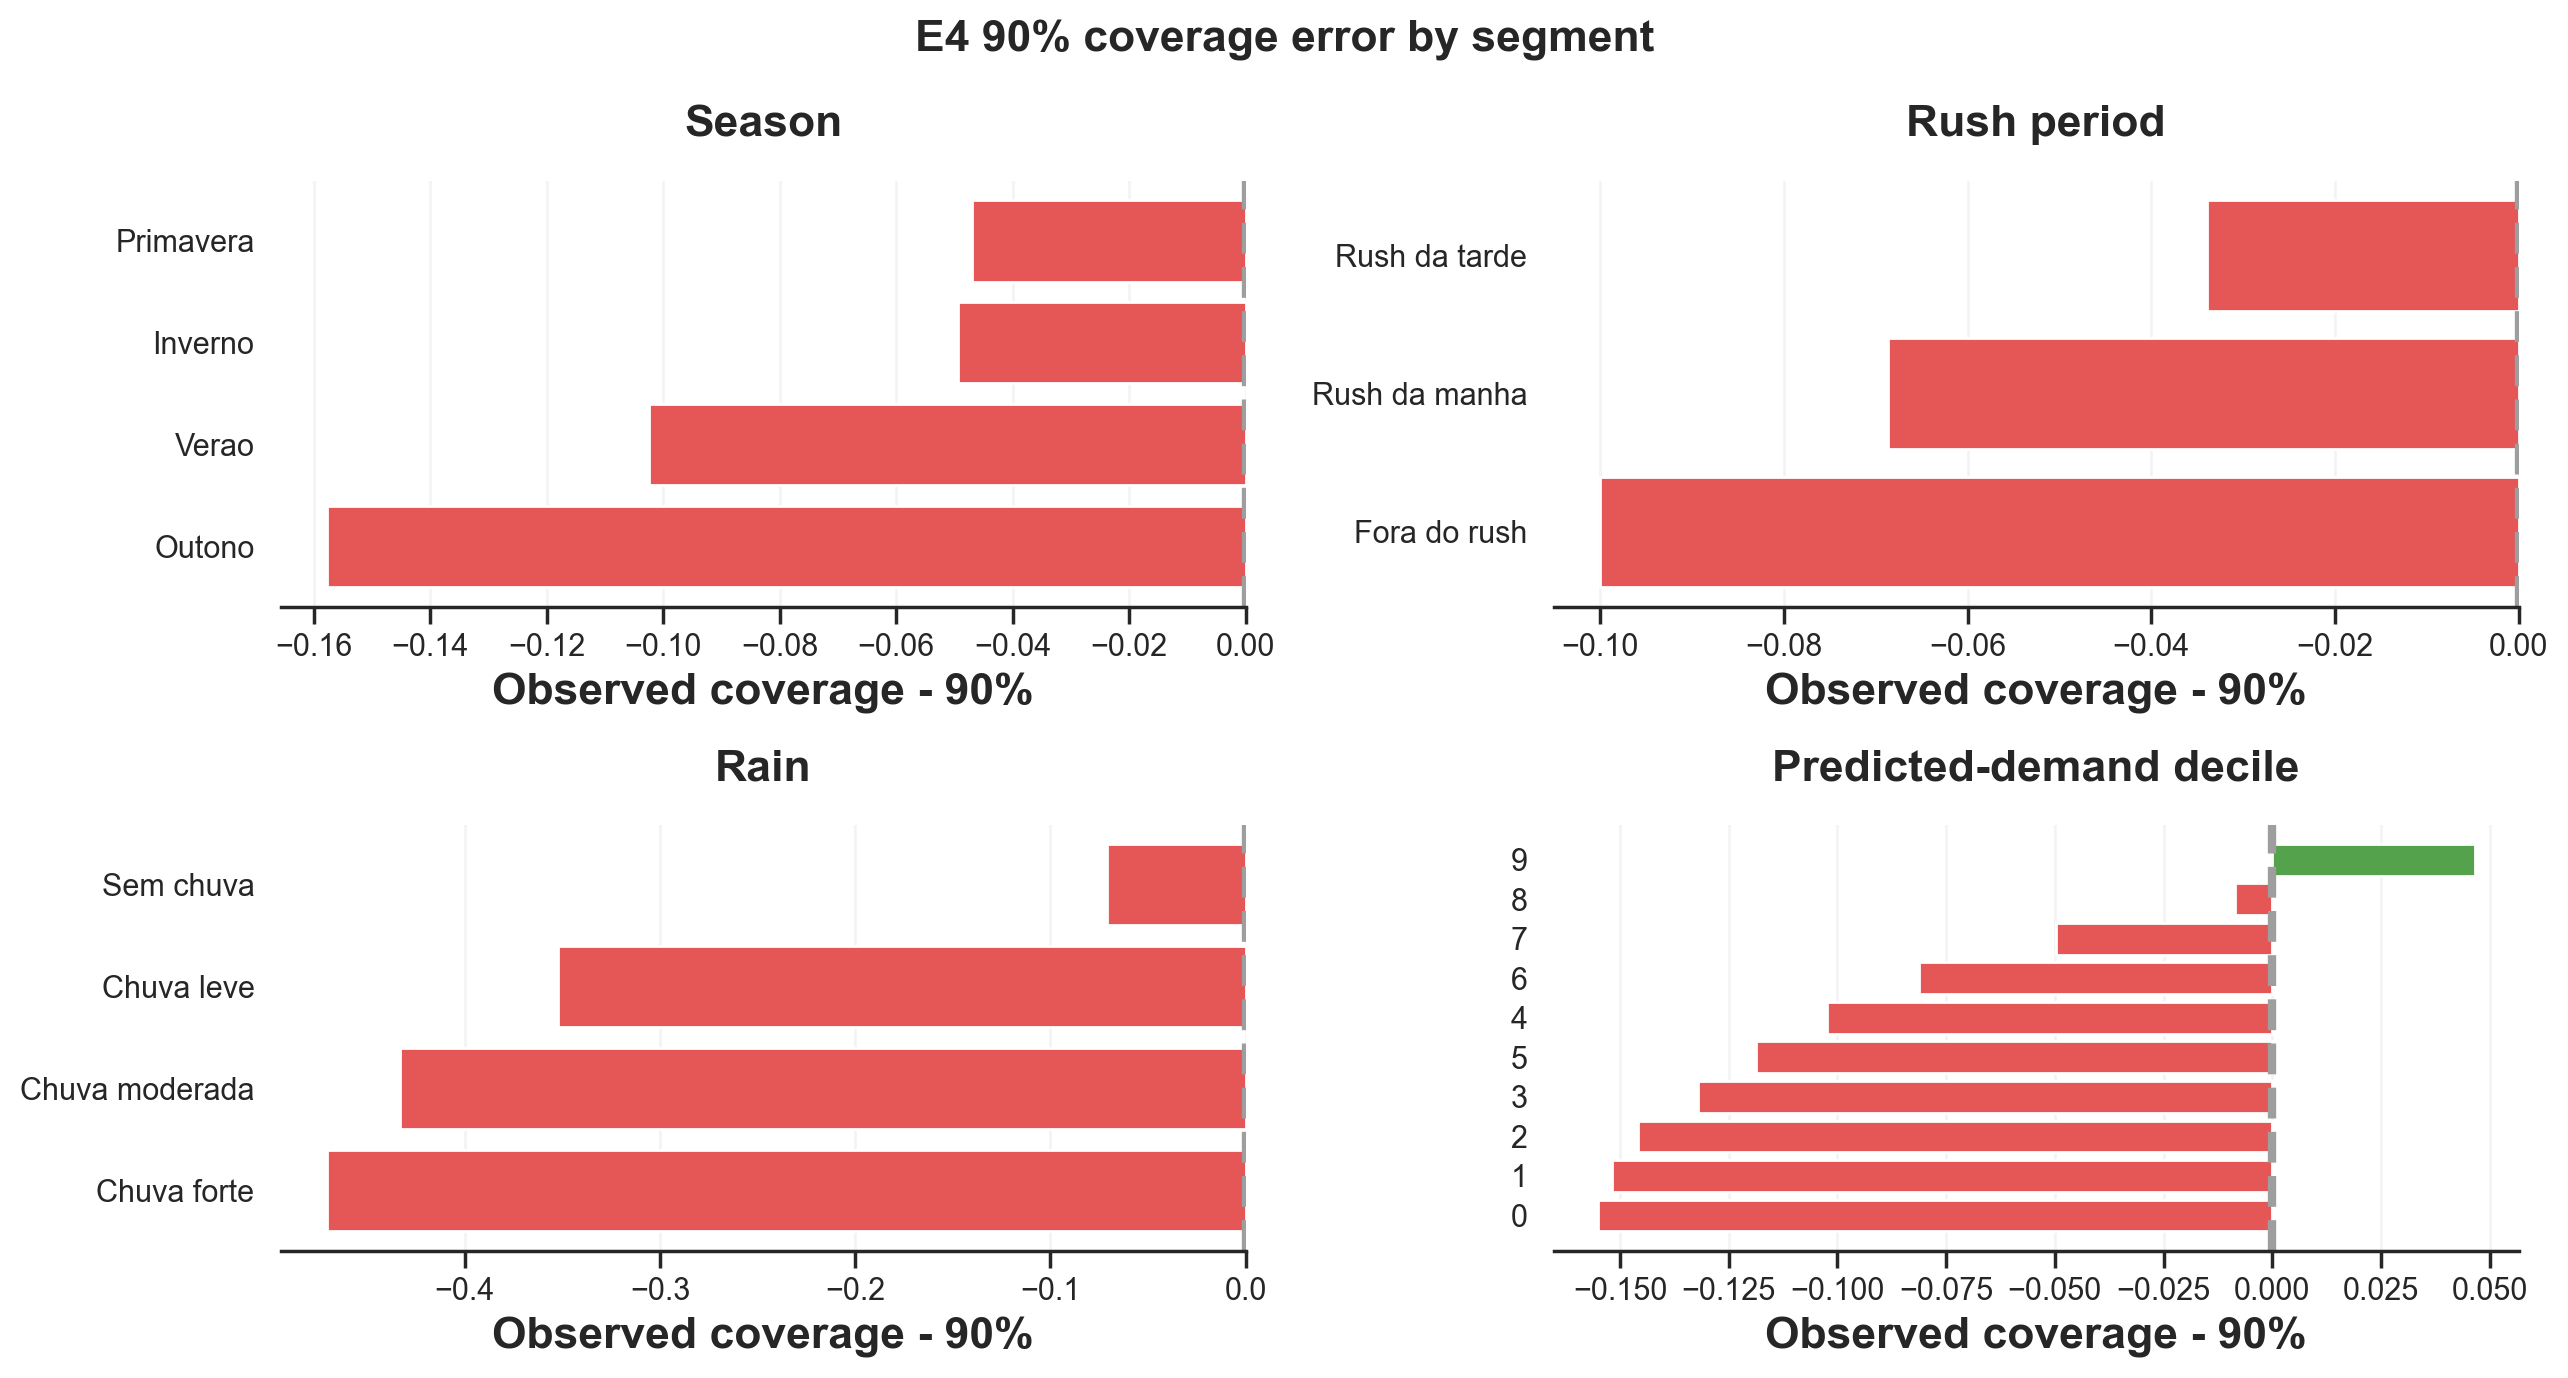

'No point successor was identified. Champion E0 was retained, while E4 remained only an experimental candidate for uncertainty modeling and still requires additional calibration.'

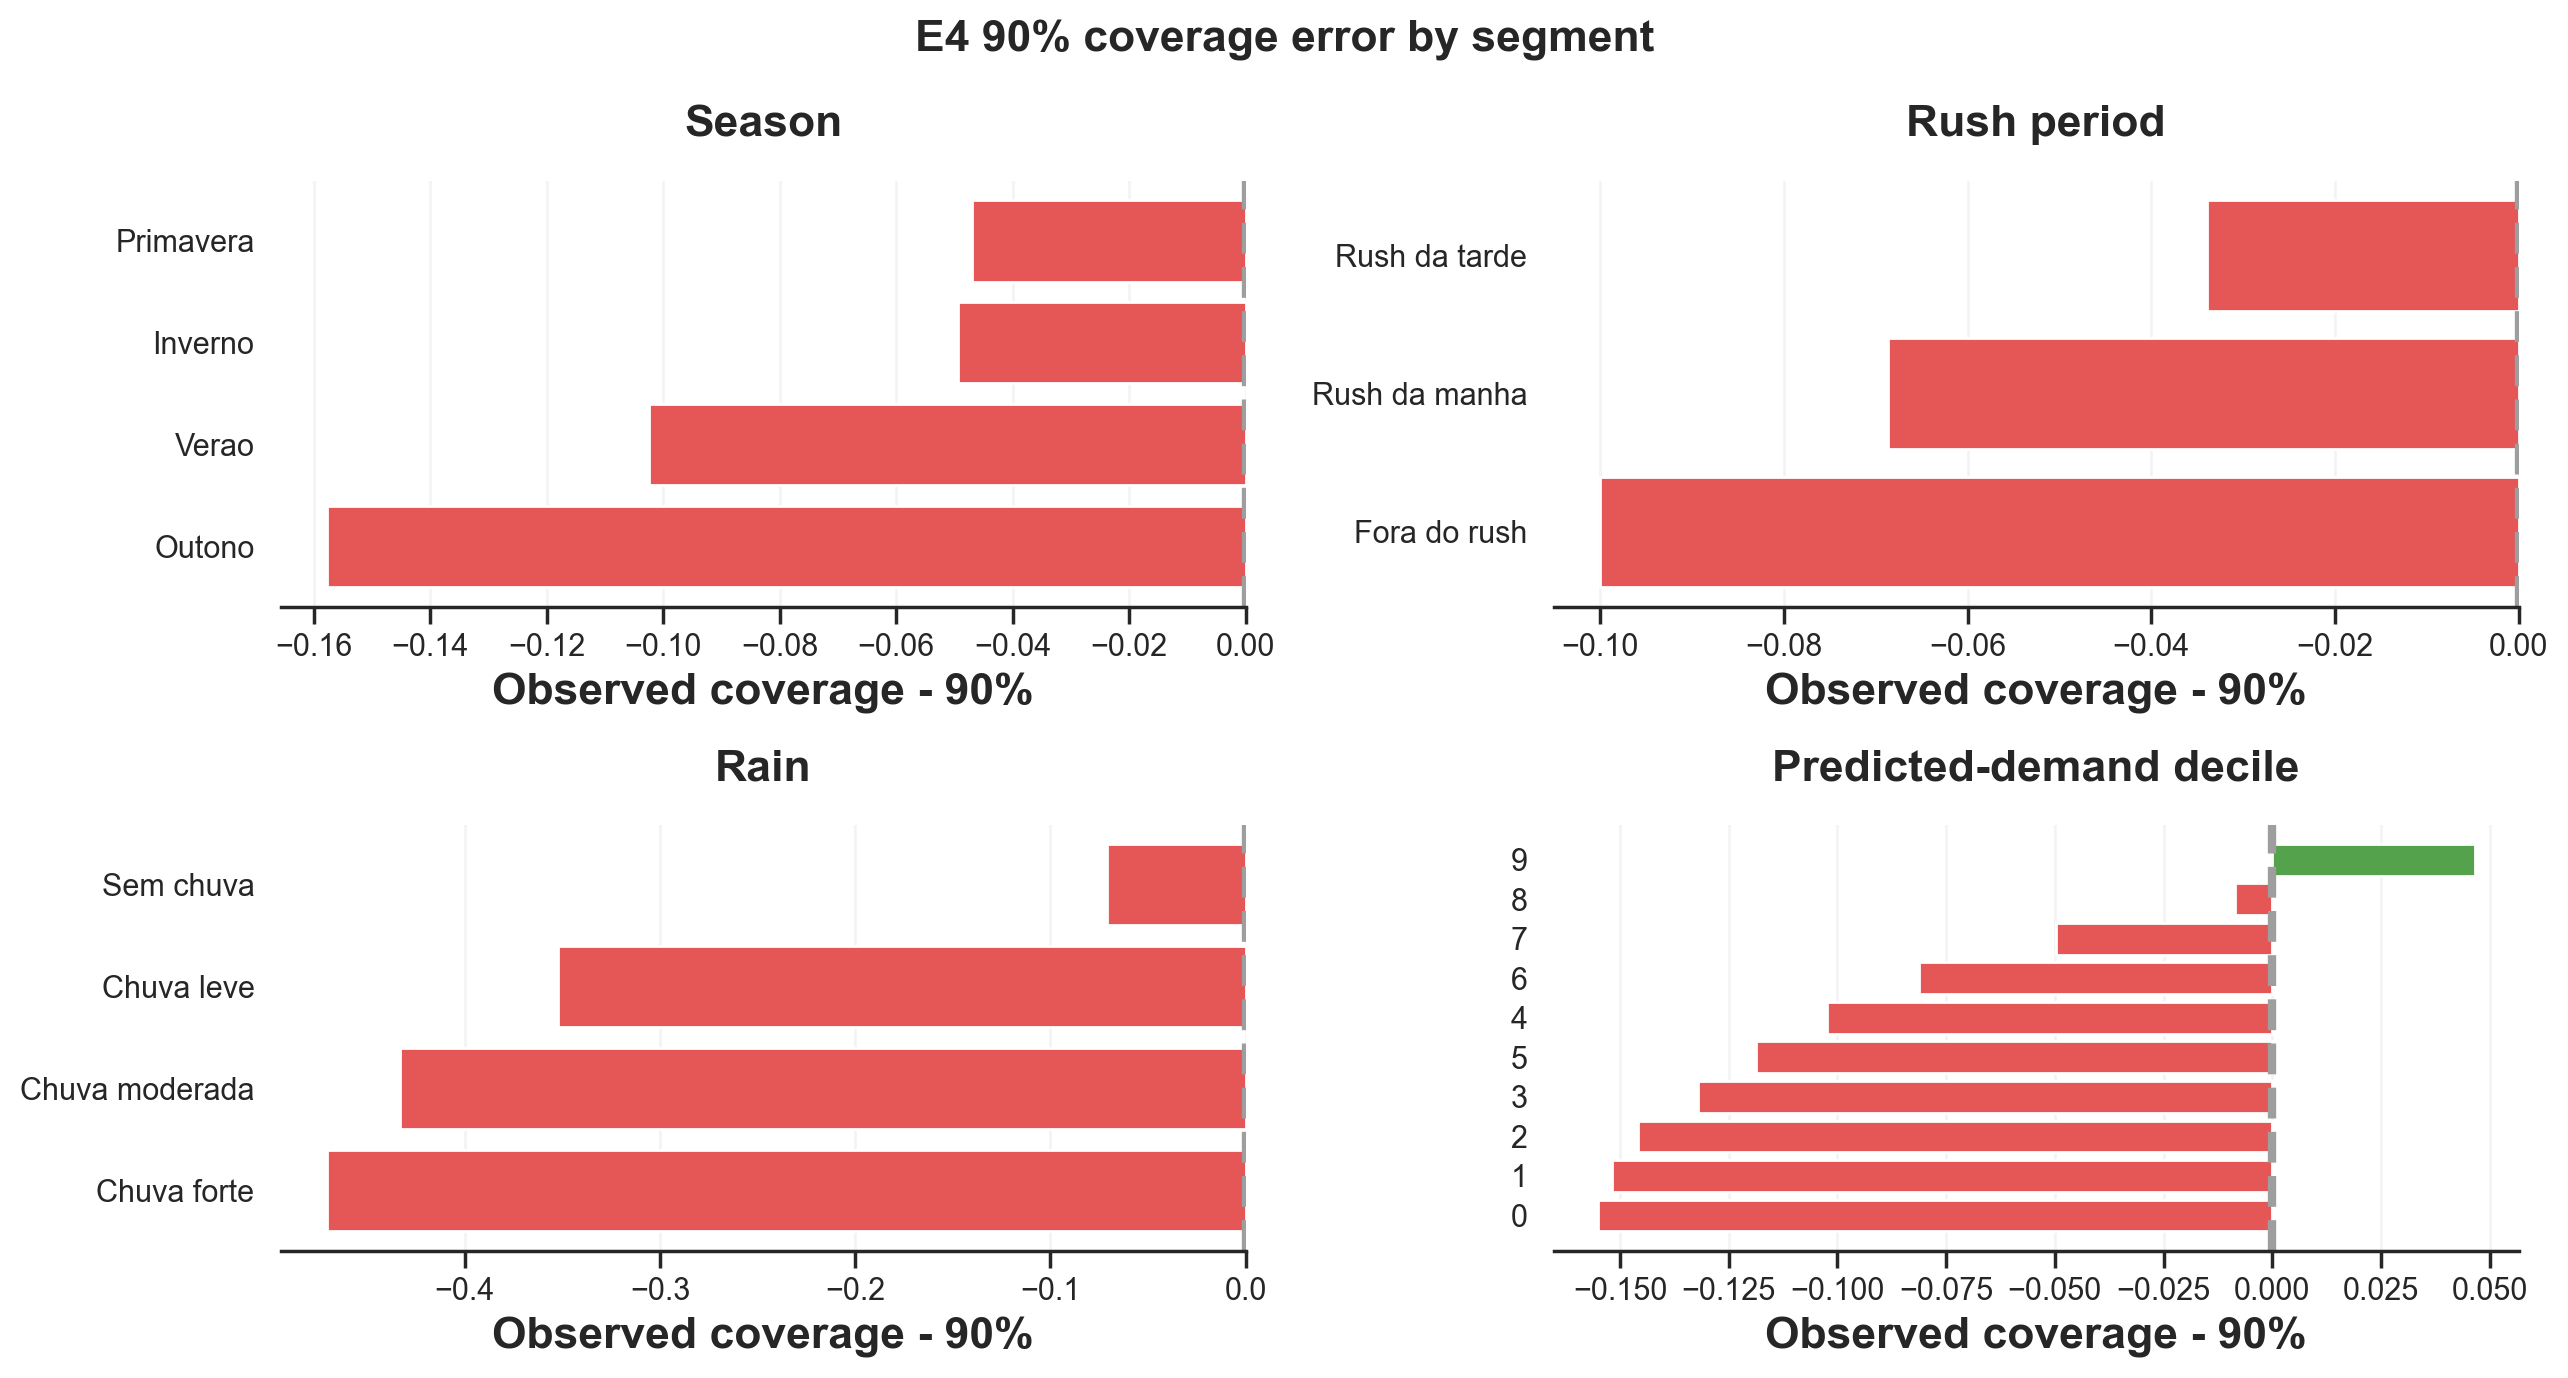

In [15]:
display(reports.segment_metrics_report(results, 'Rush_Period', lang=lang))
display(reports.segment_metrics_report(results, 'Seasons', lang=lang))
display(reports.segment_metrics_report(results, 'Rainfall Cat', lang=lang))
display(reports.friday_18_report(results, lang=lang))
display(reports.plot_segment_coverage(results, lang=lang))
reports.successor_message(results, lang=lang)

### Insight

>E0 was retained as the point Champion. Across the normal-operation folds, weighted MAE remained at 840.165, with weighted R² of 0.857 and mean R² of 0.839. E1, E2, and E3 did not reduce point error, while E4 preserved exactly the same point predictions as E3 and therefore cannot be treated as a point successor.
>
>E4 was retained only as an experimental candidate for the uncertainty layer. The average width of the 90% interval was reduced to 4,501.5 bicycles/hour and the Winkler score fell to 6,530.4, but observed coverage remained at 81.0%. Because the scale multiplier frequently collapsed to its floor of 0.25, the next hypothesis should introduce an additional temporal calibration layer without using the holdout.


## 14. Synthesis

The dynamic architecture was preserved: baseline E0 was rebuilt from the manifest, and every trainable component remained inside the pipeline. The new hypotheses were attached as explicit experimental blocks without modifying the already frozen Champion.

The final interpretation was organized around three questions. The first asked whether the central prediction improved, and the answer was no. E0 retained a weighted MAE of 840.165, weighted R² of 0.857, and mean R² of 0.839. E1 increased weighted MAE to 940.308, E2 increased it to 981.579, and E3/E4 remained at 929.472, with weighted R² of 0.830.

The second question asked whether the intervals became calibrated. E2 and E3 became excessively dispersed, with coverage near 99.5% for the nominal 90% interval and an average width above 16,000 bicycles/hour. E4 reduced negative log-likelihood to 0.946, narrowed the average 90% interval to 4,501.5, and reduced the Winkler score to 6,530.4, but remained undercalibrated, delivering only 81.0% observed coverage.

The third question asked whether the temporal dependence of variance was reduced in an operationally useful way. The answer was again no. Residual autocorrelation, squared-residual autocorrelation, and the ARCH diagnostics remained elevated, so E0 continued to be the more defensible point Champion.

No point successor should be frozen from this notebook. The next experimental hypothesis was defined as temporal conformal calibration over E0 and/or E4, to be addressed in Notebook 07. The holdout was not reopened at this stage, and any future candidate will still require a new independent window before confirmation.


### Methodological Reference

Prokhorenkova, L.; Gusev, G.; Vorobev, A.; Dorogush, A. V.; Gulin, A. (2018). CatBoost: unbiased boosting with categorical features. Advances in Neural Information Processing Systems 31.

Malinin, A.; Prokhorenkova, L.; Ustimenko, A. (2021). Uncertainty in Gradient Boosting via Ensembles. 9th International Conference on Learning Representations.

Duan, T.; Avati, A.; Ding, D. Y.; Thai, K. K.; Basu, S.; Ng, A.; Schuler, A. (2020). NGBoost: Natural Gradient Boosting for Probabilistic Prediction. Proceedings of the 37th International Conference on Machine Learning.

Engle, R. F. (1982). Autoregressive Conditional Heteroscedasticity with Estimates of the Variance of United Kingdom Inflation. Econometrica, 50(4), 987-1007.

Gneiting, T.; Balabdaoui, F.; Raftery, A. E. (2007). Probabilistic Forecasts, Calibration and Sharpness. Journal of the Royal Statistical Society: Series B, 69(2), 243-268.

Gneiting, T.; Raftery, A. E. (2007). Strictly Proper Scoring Rules, Prediction, and Estimation. Journal of the American Statistical Association, 102(477), 359-378.

Bergmeir, C.; Hyndman, R. J.; Koo, B. (2018). A note on the validity of cross-validation for evaluating autoregressive time series prediction. Computational Statistics & Data Analysis, 120, 70-83.
